In [ ]:
import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings('ignore')

# ── FUNCIONES DE PARSEO ──────────────────────────────────────────────────
def parse_eu_number(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip().replace('%', '').replace(' ', '')
    s = s.replace('.', '').replace(',', '.')
    try:
        return float(s)
    except (ValueError, TypeError):
        return np.nan

def parse_us_number(s):
    if pd.isna(s):
        return np.nan
    s = str(s).strip().replace('%', '').replace(' ', '').replace(',', '')
    try:
        return float(s)
    except (ValueError, TypeError):
        return np.nan

def parse_eu_date(s):
    return pd.to_datetime(s, format='%d.%m.%Y', errors='coerce')

def parse_us_date(s):
    return pd.to_datetime(s, format='%m/%d/%Y', errors='coerce')

# ── CARGA DE LOS 6 CSVs DIARIOS ──────────────────────────────────────────
# Nota: Se asume que los archivos están en la ruta /content/ (Google Colab)
try:
    ibex_raw  = pd.read_csv('/content/IBEX 35 Historical Data.csv')
    stoxx_raw = pd.read_csv('/content/Datos históricos del Euro Stoxx 50.csv')
    sp_raw    = pd.read_csv('/content/Datos históricos del S&P 500.csv')
    vix_raw   = pd.read_csv('/content/Datos históricos del S&P 500 VIX (2).csv')
    b10_raw   = pd.read_csv('/content/español a 10 años Datos Históricos Rendimiento de Bonos (1).csv')
    b1_raw    = pd.read_csv('/content/español a 1 año Datos Históricos Rendimiento de Bonos (1).csv')
except FileNotFoundError as e:
    print(f"Error al cargar archivos: {e}")

# Procesamiento de fechas y precios iniciales
ibex = pd.DataFrame({
    'date':       ibex_raw['Date'].apply(parse_us_date),
    'ibex_close': ibex_raw['Price'].apply(parse_us_number),
    'ibex_high':  ibex_raw['High'].apply(parse_us_number),
    'ibex_low':   ibex_raw['Low'].apply(parse_us_number),
}).dropna(subset=['date']).sort_values('date')

stoxx = pd.DataFrame({
    'date':        stoxx_raw['Fecha'].apply(parse_eu_date),
    'stoxx_close': stoxx_raw['Último'].apply(parse_eu_number),
    'stoxx_high':  stoxx_raw['Máximo'].apply(parse_eu_number),
    'stoxx_low':   stoxx_raw['Mínimo'].apply(parse_eu_number),
}).dropna(subset=['date']).sort_values('date')

sp = pd.DataFrame({
    'date':        sp_raw['Fecha'].apply(parse_eu_date),
    'sp_close':    sp_raw['Último'].apply(parse_eu_number),
    'sp_high':     sp_raw['Máximo'].apply(parse_eu_number),
    'sp_low':      sp_raw['Mínimo'].apply(parse_eu_number),
}).dropna(subset=['date']).sort_values('date')

vix = pd.DataFrame({
    'date':        vix_raw['Fecha'].apply(parse_eu_date),
    'vix_close':   vix_raw['Último'].apply(parse_eu_number),
    'vix_high':    vix_raw['Máximo'].apply(parse_eu_number),
    'vix_low':     vix_raw['Mínimo'].apply(parse_eu_number),
}).dropna(subset=['date']).sort_values('date')

b10 = pd.DataFrame({
    'date':         b10_raw['Fecha'].apply(parse_eu_date),
    'bond10_close': b10_raw['Último'].apply(parse_eu_number),
}).dropna(subset=['date']).sort_values('date')

b1 = pd.DataFrame({
    'date':        b1_raw['Fecha'].apply(parse_eu_date),
    'bond1_close': b1_raw['Último'].apply(parse_eu_number),
}).dropna(subset=['date']).sort_values('date')

# ── MERGE DIARIO ─────────────────────────────────────────────────────────
df_daily = ibex.copy()
for other in [stoxx, sp, vix, b10, b1]:
    df_daily = df_daily.merge(other, on='date', how='left')
df_daily = df_daily.sort_values('date').set_index('date')

# ── RESAMPLE A SEMANAL (cierre = viernes) ────────────────────────────────
OHLC_MAP = {
    'ibex_close': 'last',  'ibex_high': 'max',  'ibex_low': 'min',
    'stoxx_close': 'last', 'stoxx_high': 'max', 'stoxx_low': 'min',
    'sp_close': 'last',    'sp_high': 'max',    'sp_low': 'min',
    'vix_close': 'last',   'vix_high': 'max',   'vix_low': 'min',
    'bond10_close': 'last', 'bond1_close': 'last',
}
d = df_daily.resample('W-FRI').agg(OHLC_MAP).dropna(subset=['ibex_close', 'sp_close'])

ALL_LAGS = [1, 2, 3, 4, 5, 10, 20, 50]
ALL_EMA  = [2, 3, 4, 5, 10, 20, 50]
RET_COLS = ['ibex_ret', 'stoxx_ret', 'sp_ret', 'vix_ret', 'bond10_ret', 'bond1_ret']
HL_ASSETS = [('ibex', 'ibex_high', 'ibex_low'), ('stoxx', 'stoxx_high', 'stoxx_low'),
             ('sp', 'sp_high', 'sp_low'),       ('vix', 'vix_high', 'vix_low')]

# ── RETORNOS SEMANALES ───────────────────────────────────────────────────
for col in ['ibex', 'stoxx', 'sp', 'vix', 'bond10', 'bond1']:
    d[f'{col}_ret'] = d[f'{col}_close'].pct_change().clip(-0.3, 0.3)

# ── TARGET SIN DATA LEAKAGE ──────────────────────────────────────────────
d['TARGET_ibex_ret_fwd1'] = d['ibex_ret'].shift(-1)

# ── FEATURES POR ACTIVO ──────────────────────────────────────────────────
for col in RET_COLS:
    px = col.replace('_ret', '')
    # Lags y EMAs
    for l in ALL_LAGS:
        d[f'{col}_lag{l}'] = d[col].shift(l)
    for w in ALL_EMA:
        d[f'{col}_ema{w}'] = d[col].ewm(span=w, adjust=False).mean()

    # MACD
    e12 = d[col].ewm(span=12, adjust=False).mean()
    e26 = d[col].ewm(span=26, adjust=False).mean()
    macd = e12 - e26
    sig  = macd.ewm(span=9, adjust=False).mean()
    d[f'{px}_macd_line']   = macd
    d[f'{px}_macd_signal'] = sig
    d[f'{px}_macd_hist']   = macd - sig

    # RSI
    for w in [14, 7]:
        g  = d[col].clip(lower=0)
        l_ = (-d[col]).clip(lower=0)
        ag = g.ewm(com=w-1, min_periods=w).mean()
        al = l_.ewm(com=w-1, min_periods=w).mean()
        d[f'{px}_rsi{w}'] = 100 - 100 / (1 + ag / al.replace(0, np.nan))

    # Momentum
    for w in [2, 3, 4, 5, 10, 20]:
        d[f'{px}_mom{w}'] = d[col].rolling(w).sum()

    # Bandas de Bollinger sobre retornos
    for w in [20, 5]:
        rs   = d[col].rolling(w).std()
        mabs = d[col].abs().rolling(w).mean().replace(0, np.nan)
        rm   = d[col].rolling(w).mean()
        d[f'{px}_bb_width{w}'] = (4 * rs / mabs).replace([np.inf, -np.inf], np.nan)
        d[f'{px}_bb_pos{w}']   = (d[col] - (rm - 2 * rs)) / (4 * rs).replace(0, np.nan)

    # Ratios de Volatilidad
    vs = d[col].rolling(5).std()
    vl = d[col].rolling(20).std()
    d[f'{px}_volratio_5_20'] = (vs / vl.replace(0, np.nan)).replace([np.inf, -np.inf], np.nan)
    d[f'{px}_autocorr1_10'] = d[col].rolling(10).apply(
        lambda x: pd.Series(x).autocorr(lag=1), raw=False)

# ── VOLATILIDAD INTRADIARIA HL ────────────────────────────────────────────
for name, hc, lc in HL_ASSETS:
    vc = f'{name}_hl_vol'
    d[vc] = ((d[hc] - d[lc]) / d[lc]).replace([np.inf, -np.inf], np.nan)
    for l in ALL_LAGS:
        d[f'{vc}_lag{l}'] = d[vc].shift(l)
    for w in ALL_EMA:
        d[f'{vc}_ema{w}'] = d[vc].ewm(span=w, adjust=False).mean()
    d[f'{name}_hl_volratio_5_20'] = (
        d[vc].rolling(5).mean() / d[vc].rolling(20).mean().replace(0, np.nan)
    ).replace([np.inf, -np.inf], np.nan)

# ── YIELD SPREAD ─────────────────────────────────────────────────────────
d['yield_spread']     = d['bond10_close'] - d['bond1_close']
d['yield_spread_ret'] = d['yield_spread'].pct_change().clip(-0.5, 0.5)
for l in ALL_LAGS:
    d[f'yield_spread_ret_lag{l}'] = d['yield_spread_ret'].shift(l)
for w in ALL_EMA:
    d[f'yield_spread_ret_ema{w}'] = d['yield_spread_ret'].ewm(span=w, adjust=False).mean()

# ── VIX FEATURES ─────────────────────────────────────────────────────────
d['vix_level']      = d['vix_close']
d['vix_ma20_ratio'] = (d['vix_close'] / d['vix_close'].rolling(20).mean()).replace([np.inf, -np.inf], np.nan)
d['vix_ma5_ratio']  = (d['vix_close'] / d['vix_close'].rolling(5).mean()).replace([np.inf, -np.inf], np.nan)
d['vix_zscore20']   = ((d['vix_close'] - d['vix_close'].rolling(20).mean()) /
                       d['vix_close'].rolling(20).std().replace(0, np.nan))
d['vix_regime']     = (
    d['vix_close'] > d['vix_close'].rolling(104, min_periods=52).quantile(0.75)
).astype(int)

# ── CORRELACIONES ROLLING ─────────────────────────────────────────────────
d['corr_ibex_sp500_10'] = d['ibex_ret'].rolling(10).corr(d['sp_ret'])
d['corr_ibex_sp500_30'] = d['ibex_ret'].rolling(30).corr(d['sp_ret'])
d['corr_ibex_stoxx_10'] = d['ibex_ret'].rolling(10).corr(d['stoxx_ret'])
d['corr_ibex_stoxx_30'] = d['ibex_ret'].rolling(30).corr(d['stoxx_ret'])
d['corr_ibex_vix_10']   = d['ibex_ret'].rolling(10).corr(d['vix_ret'])
d['corr_ibex_vix_30']   = d['ibex_ret'].rolling(30).corr(d['vix_ret'])

# ── SPREAD DE MOMENTUM ───────────────────────────────────────────────────
d['spread_ibex_sp_mom5']     = d['ibex_ret'].rolling(5).sum() - d['sp_ret'].rolling(5).sum()
d['spread_ibex_stoxx_mom5']  = d['ibex_ret'].rolling(5).sum() - d['stoxx_ret'].rolling(5).sum()
d['spread_ibex_sp_mom20']    = d['ibex_ret'].rolling(20).sum() - d['sp_ret'].rolling(20).sum()
d['spread_ibex_stoxx_mom20'] = d['ibex_ret'].rolling(20).sum() - d['stoxx_ret'].rolling(20).sum()

# ── EFECTOS CALENDARIO ───────────────────────────────────────────────────
d['month_sin'] = np.sin(2 * np.pi * d.index.month / 12)
d['month_cos'] = np.cos(2 * np.pi * d.index.month / 12)

# ── LIMPIEZA Y EXPORTAR ───────────────────────────────────────────────────
RAW_COLS = ['ibex_close', 'ibex_high', 'ibex_low',
            'stoxx_close', 'stoxx_high', 'stoxx_low',
            'sp_close', 'sp_high', 'sp_low',
            'vix_close', 'vix_high', 'vix_low',
            'bond10_close', 'bond1_close', 'yield_spread']

TARGET = 'TARGET_ibex_ret_fwd1'
FEATURES = [c for c in d.columns if c not in RAW_COLS + [TARGET]]

df_model = d[FEATURES + [TARGET]].dropna()
df_model.index.name = 'date'
df_model.reset_index().to_csv('ibex_tfg_weekly.csv', index=False)

print(f"Dataset final: {df_model.shape[0]} filas x {df_model.shape[1]} columnas")

Dataset final: 697 filas x 300 columnas


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
import warnings

warnings.filterwarnings('ignore')

# --- 1. CARGA Y PREPROCESAMIENTO DE DATOS ---
try:
    df = pd.read_csv('/content/ibex_tfg_weekly.csv')
except FileNotFoundError:
    raise FileNotFoundError("No se encuentra el archivo de datos. Asegúrate de ejecutar la celda de preprocesamiento correctamente.")

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

target_col = df.columns[-1]
y = df[target_col]
X = df.drop(columns=[target_col, 'date'])
X_num = X.select_dtypes(include=[np.number])

print(f'Usando como target: {target_col}')

# --- 2. DEFINICIÓN DEL EXPERIMENTO ---
def run_exhaustive_experiment():
    winsor_limits = [(0.01, 0.01), (0.025, 0.025), (0.05, 0.05)]
    pca_sets = [
        [0], [0, 1], [0, 2], [0, 3], [0, 4],
        [0, 1, 2], [0, 1, 3], [0, 1, 4],
        [0, 1, 2, 3], [0, 1, 3, 5], [0, 1, 3, 7],
        [0, 1, 2, 3, 4, 5], [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
    ]
    models = {
        'RF': [
            {'n_estimators': 100, 'max_depth': 3, 'random_state': 42},
            {'n_estimators': 200, 'max_depth': 4, 'random_state': 42},
            {'n_estimators': 300, 'max_depth': 5, 'random_state': 42}
        ],
        'XGB': [
            {'n_estimators': 100, 'learning_rate': 0.03, 'max_depth': 3, 'random_state': 42},
            {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 3, 'random_state': 42},
            {'n_estimators': 200, 'learning_rate': 0.01, 'max_depth': 4, 'random_state': 42}
        ]
    }

    tscv = TimeSeriesSplit(n_splits=5)
    results = []

    for w_lim in winsor_limits:
        for pca_set in pca_sets:
            for m_name, param_list in models.items():
                for params in param_list:
                    fold_acc = []

                    for train_idx, test_idx in tscv.split(X_num):
                        X_tr, X_te = X_num.iloc[train_idx].copy(), X_num.iloc[test_idx].copy()
                        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

                        # Preprocesamiento: Winsorización
                        for col in X_tr.columns:
                            l = X_tr[col].quantile(w_lim[0])
                            u = X_tr[col].quantile(1 - w_lim[1])
                            X_tr[col] = X_tr[col].clip(l, u)
                            X_te[col] = X_te[col].clip(l, u)

                        # Escalado
                        sc = StandardScaler()
                        X_tr_s = sc.fit_transform(X_tr)
                        X_te_s = sc.transform(X_te)

                        # PCA
                        pca = PCA(n_components=max(pca_set) + 1)
                        X_tr_p = pca.fit_transform(X_tr_s)
                        X_te_p = pca.transform(X_te_s)

                        # Entrenamiento y Predicción
                        model = RandomForestRegressor(**params) if m_name == 'RF' else XGBRegressor(**params)
                        model.fit(X_tr_p[:, pca_set], y_tr)
                        preds = model.predict(X_te_p[:, pca_set])

                        # HOMOGENEIZACIÓN DEL SIGNO (0 es positivo/subida)
                        # Transformamos a 1 (sube) y -1 (baja)
                        y_te_sign = np.where(y_te.values >= 0, 1, -1)
                        preds_sign = np.where(preds >= 0, 1, -1)

                        acc = (preds_sign == y_te_sign).mean()
                        fold_acc.append(acc)

                    if fold_acc:
                        results.append({
                            'model': m_name,
                            'params': str(params),
                            'winsor': w_lim,
                            'pca': pca_set,
                            'accuracy': np.mean(fold_acc)
                        })

    return pd.DataFrame(results).sort_values('accuracy', ascending=False)

# --- 3. EJECUCIÓN ---
full_results = run_exhaustive_experiment()
print("Top 20 configuraciones por Accuracy:")
display(full_results.head(20))

Usando como target: TARGET_ibex_ret_fwd1
Top 20 configuraciones por Accuracy:


,model,params,winsor,pca,accuracy
135,XGB,"{'n_estimators': 100, 'learning_rate': 0.03, '...","(0.025, 0.025)","[0, 1, 3, 5]",0.586207
133,RF,"{'n_estimators': 200, 'max_depth': 4, 'random_...","(0.025, 0.025)","[0, 1, 3, 5]",0.584483
140,RF,"{'n_estimators': 300, 'max_depth': 5, 'random_...","(0.025, 0.025)","[0, 1, 3, 7]",0.584483
139,RF,"{'n_estimators': 200, 'max_depth': 4, 'random_...","(0.025, 0.025)","[0, 1, 3, 7]",0.581034
138,RF,"{'n_estimators': 100, 'max_depth': 3, 'random_...","(0.025, 0.025)","[0, 1, 3, 7]",0.575862
141,XGB,"{'n_estimators': 100, 'learning_rate': 0.03, '...","(0.025, 0.025)","[0, 1, 3, 7]",0.575862
36,RF,"{'n_estimators': 100, 'max_depth': 3, 'random_...","(0.01, 0.01)","[0, 1, 3]",0.575862
61,RF,"{'n_estimators': 200, 'max_depth': 4, 'random_...","(0.01, 0.01)","[0, 1, 3, 7]",0.574138
134,RF,"{'n_estimators': 300, 'max_depth': 5, 'random_...","(0.025, 0.025)","[0, 1, 3, 5]",0.572414
60,RF,"{'n_estimators': 100, 'max_depth': 3, 'random_...","(0.01, 0.01)","[0, 1, 3, 7]",0.572414


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
import warnings

warnings.filterwarnings('ignore')

# --- 1. CARGA Y PREPROCESAMIENTO DE DATOS ---
try:
    df = pd.read_csv('/content/ibex_tfg_weekly.csv')
except FileNotFoundError:
    raise FileNotFoundError("Archivo no encontrado en /content/. Verifica la celda de preprocesamiento.")

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

target_col = df.columns[-1]
y = df[target_col]
X = df.drop(columns=[target_col]) # Mantenemos 'date' momentáneamente para filtrar
X_num_cols = X.select_dtypes(include=[np.number]).columns

print(f'Iniciando experimento. Target: {target_col}')
print('Restricción: Años 2020 y 2022 excluidos del TRAIN, pero presentes en TEST.')

# --- 2. DEFINICIÓN DEL EXPERIMENTO ---
def run_exhaustive_experiment_filtered():
    winsor_limits = [(0.01, 0.01), (0.025, 0.025), (0.05, 0.05)]
    pca_sets = [
        [0], [0, 1], [0, 2], [0, 3], [0, 4],
        [0, 1, 2], [0, 1, 3], [0, 1, 4],
        [0, 1, 2, 3], [0, 1, 3, 5], [0, 1, 3, 7],
        [0, 1, 2, 3, 4, 5], [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
    ]
    models = {
        'RF': [
            {'n_estimators': 100, 'max_depth': 3, 'random_state': 42},
            {'n_estimators': 200, 'max_depth': 4, 'random_state': 42},
            {'n_estimators': 300, 'max_depth': 5, 'random_state': 42}
        ],
        'XGB': [
            {'n_estimators': 100, 'learning_rate': 0.03, 'max_depth': 3, 'random_state': 42},
            {'n_estimators': 100, 'learning_rate': 0.05, 'max_depth': 3, 'random_state': 42},
            {'n_estimators': 200, 'learning_rate': 0.01, 'max_depth': 4, 'random_state': 42}
        ]
    }

    tscv = TimeSeriesSplit(n_splits=5)
    results = []

    for w_lim in winsor_limits:
        for pca_set in pca_sets:
            for m_name, param_list in models.items():
                for params in param_list:
                    fold_acc = []

                    for train_idx, test_idx in tscv.split(df):
                        # Separación inicial
                        X_tr_raw = df.iloc[train_idx].copy()
                        X_te_raw = df.iloc[test_idx].copy()

                        # --- FILTRADO DE AÑOS 2020 Y 2022 EN EL TRAIN ---
                        X_tr_filtered = X_tr_raw[~X_tr_raw['date'].dt.year.isin([2020, 2022])]

                        y_tr = X_tr_filtered[target_col]
                        X_tr = X_tr_filtered[X_num_cols]

                        # El TEST se mantiene íntegro (incluyendo 2020/2022 si aparecen)
                        y_te = X_te_raw[target_col]
                        X_te = X_te_raw[X_num_cols]

                        if len(X_tr) == 0: continue

                        # Preprocesamiento: Winsorización (basada en el Train filtrado)
                        for col in X_tr.columns:
                            l = X_tr[col].quantile(w_lim[0])
                            u = X_tr[col].quantile(1 - w_lim[1])
                            X_tr[col] = X_tr[col].clip(l, u)
                            X_te[col] = X_te[col].clip(l, u)

                        # Escalado
                        sc = StandardScaler()
                        X_tr_s = sc.fit_transform(X_tr)
                        X_te_s = sc.transform(X_te)

                        # PCA
                        pca = PCA(n_components=max(pca_set) + 1)
                        X_tr_p = pca.fit_transform(X_tr_s)
                        X_te_p = pca.transform(X_te_s)

                        # Entrenamiento y Predicción
                        model = RandomForestRegressor(**params) if m_name == 'RF' else XGBRegressor(**params)
                        model.fit(X_tr_p[:, pca_set], y_tr)
                        preds = model.predict(X_te_p[:, pca_set])

                        # Homogeneización del signo: 0 es positivo/subida
                        y_te_sign = np.where(y_te.values >= 0, 1, -1)
                        preds_sign = np.where(preds >= 0, 1, -1)

                        acc = (preds_sign == y_te_sign).mean()
                        fold_acc.append(acc)

                    if fold_acc:
                        results.append({
                            'model': m_name,
                            'params': str(params),
                            'winsor': w_lim,
                            'pca': pca_set,
                            'accuracy': np.mean(fold_acc)
                        })

    return pd.DataFrame(results).sort_values('accuracy', ascending=False)

# --- 3. EJECUCIÓN ---
full_results = run_exhaustive_experiment_filtered()
print("\nTop 20 mejores configuraciones (Sin 2020/2022 en Train):")
display(full_results.head(20))

Iniciando experimento. Target: TARGET_ibex_ret_fwd1
Restricción: Años 2020 y 2022 excluidos del TRAIN, pero presentes en TEST.

Top 20 mejores configuraciones (Sin 2020/2022 en Train):


,model,params,winsor,pca,accuracy
133,RF,"{'n_estimators': 200, 'max_depth': 4, 'random_...","(0.025, 0.025)","[0, 1, 3, 5]",0.575862
54,RF,"{'n_estimators': 100, 'max_depth': 3, 'random_...","(0.01, 0.01)","[0, 1, 3, 5]",0.568966
222,RF,"{'n_estimators': 100, 'max_depth': 3, 'random_...","(0.05, 0.05)","[0, 1, 2, 3, 4, 5]",0.568966
61,RF,"{'n_estimators': 200, 'max_depth': 4, 'random_...","(0.01, 0.01)","[0, 1, 3, 7]",0.567241
36,RF,"{'n_estimators': 100, 'max_depth': 3, 'random_...","(0.01, 0.01)","[0, 1, 3]",0.565517
210,RF,"{'n_estimators': 100, 'max_depth': 3, 'random_...","(0.05, 0.05)","[0, 1, 3, 5]",0.565517
145,RF,"{'n_estimators': 200, 'max_depth': 4, 'random_...","(0.025, 0.025)","[0, 1, 2, 3, 4, 5]",0.565517
146,RF,"{'n_estimators': 300, 'max_depth': 5, 'random_...","(0.025, 0.025)","[0, 1, 2, 3, 4, 5]",0.563793
204,RF,"{'n_estimators': 100, 'max_depth': 3, 'random_...","(0.05, 0.05)","[0, 1, 2, 3]",0.563793
139,RF,"{'n_estimators': 200, 'max_depth': 4, 'random_...","(0.025, 0.025)","[0, 1, 3, 7]",0.563793


 Dataset listo para PCA. Dimensiones: (697, 299)

--- ANÁLISIS DE VARIANZA EXPLICADA ---


,Componente,Varianza Explicada (%),Varianza Acumulada (%)
0,PC0,18.61,18.61
1,PC1,9.82,28.44
2,PC2,5.46,33.90
3,PC3,4.62,38.52
4,PC4,4.16,42.68
5,PC5,3.45,46.13
6,PC6,2.69,48.83
7,PC7,2.28,51.10
8,PC8,2.07,53.17
9,PC9,1.79,54.96



--- VARIABLES DOMINANTES POR COMPONENTE ---

Top 10 en PC0:


,PC0
stoxx_ret_ema10,0.1193
vix_ma20_ratio,-0.1155
stoxx_ret_ema20,0.1152
sp_ret_ema10,0.1139
stoxx_ret_ema5,0.1129
ibex_ret_ema10,0.1108
stoxx_ret_ema4,0.1086
sp_ret_ema5,0.1078
sp_ret_ema20,0.1077
ibex_ret_ema5,0.1076



Top 10 en PC1:


,PC1
stoxx_hl_vol_ema10,0.1347
stoxx_hl_vol_ema20,0.1303
vix_macd_hist,-0.1293
sp_hl_vol_ema10,0.1241
ibex_hl_vol_ema10,0.1239
stoxx_hl_vol_ema5,0.1200
stoxx_hl_vol_lag2,0.1197
vix_ret_ema3,-0.1188
sp_hl_vol_ema20,0.1186
vix_ret_ema2,-0.1168



Top 10 en PC3:


,PC3
bond1_ret_ema5,0.2295
bond1_ret_ema4,0.2258
bond1_ret_ema10,0.2217
bond1_macd_line,0.2212
bond1_ret_ema3,0.2170
bond1_mom4,0.2110
bond1_mom5,0.2084
bond1_mom3,0.2081
bond1_ret_ema2,0.1986
bond1_mom2,0.1963



Top 10 en PC5:


,PC5
spread_ibex_sp_mom5,0.2390
ibex_ret_ema10,0.1541
ibex_ret_ema5,0.1491
ibex_macd_line,0.1449
ibex_ret_ema4,0.1440
spread_ibex_stoxx_mom5,0.1435
ibex_ret_ema20,0.1411
ibex_mom4,0.1409
spread_ibex_sp_mom20,0.1395
ibex_rsi7,0.1387


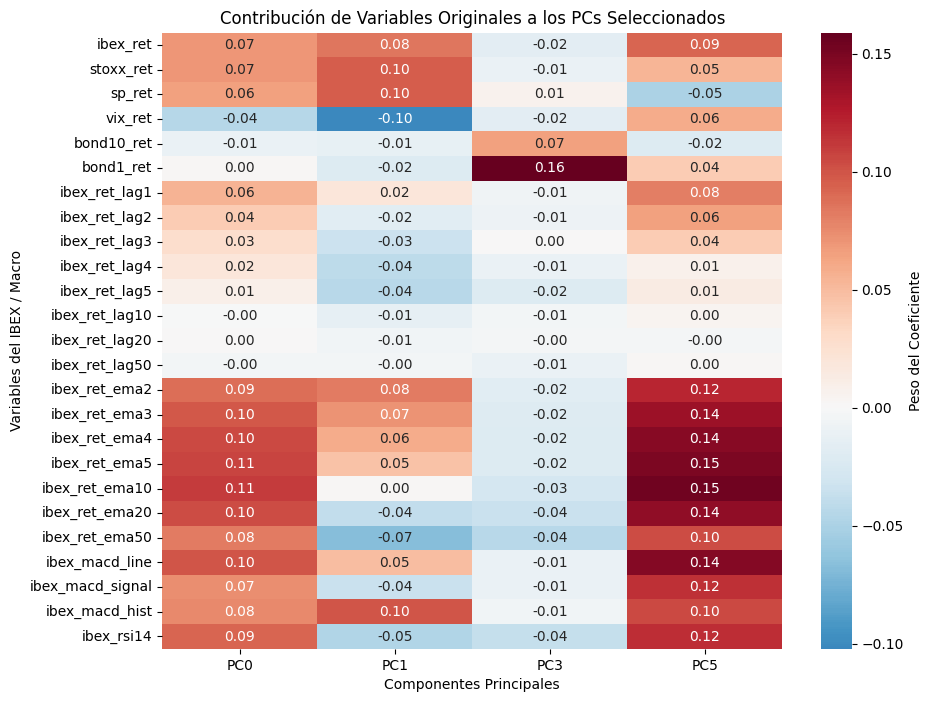

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import os

# ── 0. CARGA Y PREPARACIÓN DE DATOS ──────────────────────────────────────
file_path = '/content/ibex_tfg_weekly.csv'
if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    target_col = df.columns[-1]

    X_num = df.select_dtypes(include=[np.number]).drop(columns=[target_col] if target_col in df.columns else [])
    if 'date' in X_num.columns: X_num = X_num.drop(columns=['date'])
    print(f" Dataset listo para PCA. Dimensiones: {X_num.shape}")
else:
    print(" Error: No se encontró el archivo ibex_tfg_weekly.csv.")

# ── 1. AJUSTE DE PCA (ANÁLISIS GLOBAL) ───────────────────────────────────
sc = StandardScaler()
X_num_s = sc.fit_transform(X_num)

pca = PCA()
pca.fit(X_num_s)

# ── 2. TABLA DE VARIANZA EXPLICADA (REQUERIMIENTO 2.2) ───────────────────
varianza_df = pd.DataFrame({
    'Componente': [f'PC{i}' for i in range(len(pca.explained_variance_ratio_))],
    'Varianza Explicada (%)': pca.explained_variance_ratio_ * 100,
    'Varianza Acumulada (%)': np.cumsum(pca.explained_variance_ratio_) * 100
})

print("\n--- ANÁLISIS DE VARIANZA EXPLICADA ---")
display(varianza_df.head(15).round(2))

# ── 3. ANÁLISIS DE CONTRIBUCIÓN (LOADINGS) ───────────────────────────────

selected_indices = [0, 1, 3, 5]
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i}' for i in range(pca.n_components_)],
    index=X_num.columns
)

print("\n--- VARIABLES DOMINANTES POR COMPONENTE ---")
for idx in selected_indices:
    pc_name = f'PC{idx}'

    top_10 = loadings[pc_name].abs().sort_values(ascending=False).head(10).index
    print(f"\nTop 10 en {pc_name}:")
    display(loadings.loc[top_10, [pc_name]].round(4))

# ── 4. MAPA DE CALOR DE LAS CARGAS ───────────────────────────────────────
plt.figure(figsize=(10, 8))

sns.heatmap(
    loadings.iloc[:25, selected_indices],
    cmap='RdBu_r',
    center=0,
    annot=True,
    fmt=".2f",
    cbar_kws={'label': 'Peso del Coeficiente'}
)
plt.title('Contribución de Variables Originales a los PCs Seleccionados')
plt.xlabel('Componentes Principales')
plt.ylabel('Variables del IBEX / Macro')
plt.show()

Iniciando validación cruzada con evaluación estadística individual por fold...


,Fold,Inicio,Fin,Acc_Global (%),Recall_Baja (%),Recall_Sube (%),Kappa,RMSE,R2,PT p-val,DM p-val
0,1,2014-08-01,2016-06-17,55.56,32.00,79.59,0.12,0.0331,-0.18,0.0950,0.9239
1,2,2016-06-24,2018-05-11,47.47,41.86,51.79,-0.06,0.0223,-0.12,0.7354,0.9765
2,3,2018-05-18,2020-04-03,60.61,41.51,82.61,0.23,0.0318,-0.02,0.0046,0.4722
3,4,2020-04-10,2022-02-25,60.61,48.94,71.15,0.20,0.0318,0.01,0.0201,0.3390
4,5,2022-03-04,2024-02-02,55.56,35.56,72.22,0.08,0.0225,-0.00,0.2030,0.4310
5,6,2024-02-09,2025-12-26,62.63,61.76,63.08,0.23,0.0207,-0.01,0.0092,0.1946



PROMEDIOS GLOBALES DE LA VALIDACIÓN CRUZADA
Promedio RMSE: 0.0270
Promedio R2: -0.0533
Promedio Accuracy Global: 57.07%
Promedio Recall Baja (Cortos): 43.60%
Promedio Recall Sube (Largos): 70.07%
Promedio PT p-val: 0.1779
Promedio DM p-val: 0.5562


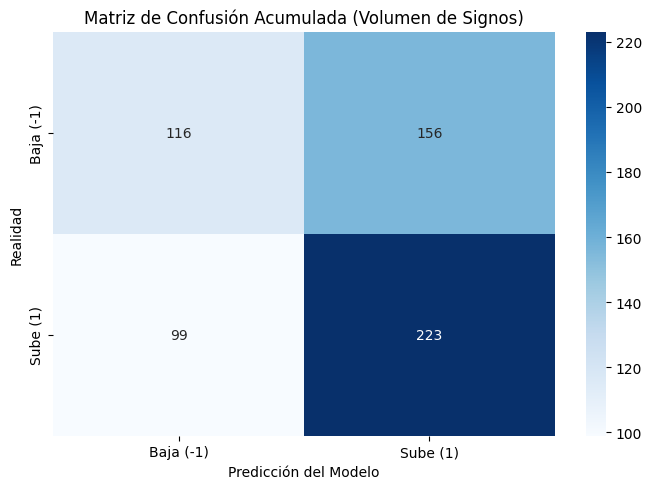

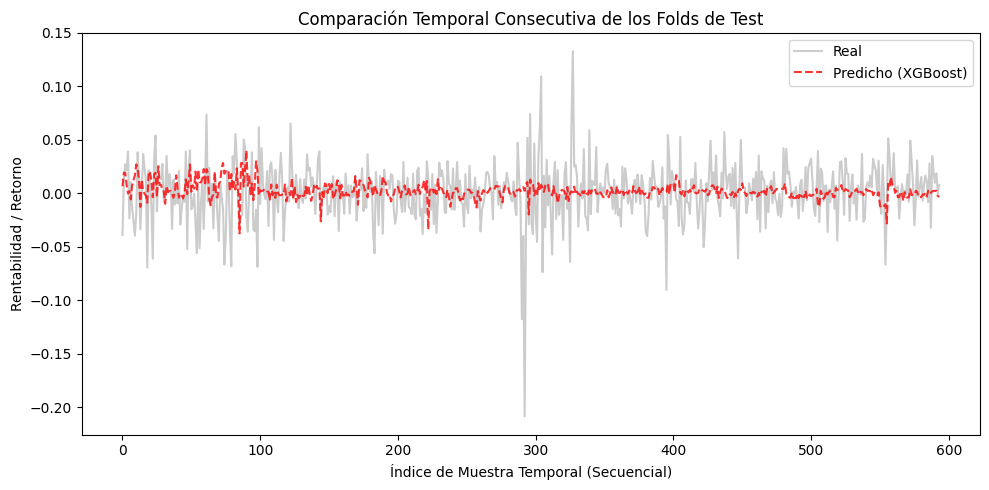

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import norm
from sklearn.metrics import (mean_squared_error, r2_score, cohen_kappa_score,
                             confusion_matrix, accuracy_score)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from xgboost import XGBRegressor
import warnings

warnings.filterwarnings('ignore')

# ── FUNCIONES DE CONTRASTES ESTADÍSTICOS ─────────────────────────────────

def pesaran_timmermann_test(y_true, y_pred):
    """Calcula el test de Pesaran-Timmermann para capacidad direccional."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    n = len(y_true)

    p_hat = (y_true == y_pred).mean()
    p_y = (y_true == 1).mean()
    p_x = (y_pred == 1).mean()
    p_star = p_y * p_x + (1 - p_y) * (1 - p_x)

    v_p_hat = (p_star * (1 - p_star)) / n
    v_p_y = (2 * p_x - 1)**2 * (p_y * (1 - p_y) / n)
    v_p_x = (2 * p_y - 1)**2 * (p_x * (1 - p_x) / n)

    v_total = v_p_hat - v_p_y - v_p_x
    if v_total <= 0: return 0.0, 1.0

    z_stat = (p_hat - p_star) / np.sqrt(v_total)
    p_value = 1 - norm.cdf(z_stat)
    return z_stat, p_value


def diebold_mariano_test(y_true, y_pred, y_benchmark, h=1):
    """Contraste DM: compara error del modelo vs Benchmark (Media Histórica)."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    y_benchmark = np.array(y_benchmark)

    e_mod = (y_true - y_pred)**2
    e_ben = (y_true - y_benchmark)**2
    d = e_ben - e_mod

    d_bar = np.mean(d)
    n = len(d)

    gamma0 = np.var(d, ddof=0)
    variance = gamma0
    for k in range(1, h):
        if n - k > 0:
            gamma_k = np.mean((d[k:] - d_bar) * (d[:-k] - d_bar))
            variance += 2 * gamma_k

    v_d = variance / n
    if v_d <= 0: return 0.0, 1.0

    dm_stat = d_bar / np.sqrt(v_d)
    p_value = 1 - norm.cdf(dm_stat)
    return dm_stat, p_value

# ── 0. CARGA DE DATOS ────────────────────────────────────────────────────

try:
    df = pd.read_csv('/content/ibex_tfg_weekly.csv')
except FileNotFoundError:
    df = pd.read_csv('ibex_tfg_weekly.csv')

date_col = 'date' if 'date' in df.columns else 'Date'
df[date_col] = pd.to_datetime(df[date_col])
df = df.sort_values(date_col)

target_col = df.columns[-1]
X_num = df.select_dtypes(include=[np.number]).drop(columns=[target_col])
y = df[target_col]

# ── 1. CONFIGURACIÓN DE PARÁMETROS ───────────────────────────────────────

best_xgb_params = {'n_estimators': 100, 'learning_rate': 0.03, 'max_depth': 3, 'random_state': 42}
best_pca_set = [0, 1, 3, 5]
best_winsor = (0.025, 0.025)

# ── 2. VALIDACIÓN CRUZADA (6 FOLDS) ──────────────────────────────────────

tscv_6 = TimeSeriesSplit(n_splits=6)
all_preds = []
all_actuals = []
fold_detailed_results = []

print("Iniciando validación cruzada con evaluación estadística individual por fold...")

for i, (train_idx, test_idx) in enumerate(tscv_6.split(X_num)):
    X_tr, X_te = X_num.iloc[train_idx].copy(), X_num.iloc[test_idx].copy()
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    mean_benchmark = y_tr.mean()
    benchmarks_fold = [mean_benchmark] * len(y_te)

    for col in X_tr.columns:
        l = X_tr[col].quantile(best_winsor[0])
        u = X_tr[col].quantile(1 - best_winsor[1])
        X_tr[col], X_te[col] = X_tr[col].clip(l, u), X_te[col].clip(l, u)

    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr)
    X_te_s = sc.transform(X_te)

    pca = PCA(n_components=max(best_pca_set) + 1)
    X_tr_p = pca.fit_transform(X_tr_s)
    X_te_p = pca.transform(X_te_s)

    model = XGBRegressor(**best_xgb_params)
    model.fit(X_tr_p[:, best_pca_set], y_tr)
    preds = model.predict(X_te_p[:, best_pca_set])

    all_preds.extend(preds)
    all_actuals.extend(y_te.values)

    y_te_sign = np.where(y_te.values >= 0, 1, -1)
    preds_sign = np.where(preds >= 0, 1, -1)

    cm = confusion_matrix(y_te_sign, preds_sign, labels=[-1, 1])
    recall_down = cm[0,0] / cm[0,:].sum() if cm[0,:].sum() > 0 else 0
    recall_up = cm[1,1] / cm[1,:].sum() if cm[1,:].sum() > 0 else 0

    z_pt, p_pt = pesaran_timmermann_test(y_te_sign, preds_sign)
    dm_stat, p_dm = diebold_mariano_test(y_te.values, preds, benchmarks_fold, h=1)

    fold_detailed_results.append({
        'Fold': i + 1,
        'Inicio': df[date_col].iloc[test_idx[0]].date(),
        'Fin': df[date_col].iloc[test_idx[-1]].date(),
        'Acc_Global (%)': round(accuracy_score(y_te_sign, preds_sign) * 100, 2),
        'Recall_Baja (%)': round(recall_down * 100, 2),
        'Recall_Sube (%)': round(recall_up * 100, 2),
        'Kappa': round(cohen_kappa_score(y_te_sign, preds_sign), 2),
        'RMSE': round(np.sqrt(mean_squared_error(y_te, preds)), 4),
        'R2': round(r2_score(y_te, preds), 2),
        'PT p-val': round(p_pt, 4),
        'DM p-val': round(p_dm, 4)
    })

summary_detailed_df = pd.DataFrame(fold_detailed_results)
display(summary_detailed_df)

# ── 3. RESUMEN ESTADÍSTICO EN TEXTO ──────────────────────────────────────

print("\n" + "="*60)
print("PROMEDIOS GLOBALES DE LA VALIDACIÓN CRUZADA")
print("="*60)
print(f"Promedio RMSE: {summary_detailed_df['RMSE'].mean():.4f}")
print(f"Promedio R2: {summary_detailed_df['R2'].mean():.4f}")
print(f"Promedio Accuracy Global: {summary_detailed_df['Acc_Global (%)'].mean():.2f}%")
print(f"Promedio Recall Baja (Cortos): {summary_detailed_df['Recall_Baja (%)'].mean():.2f}%")
print(f"Promedio Recall Sube (Largos): {summary_detailed_df['Recall_Sube (%)'].mean():.2f}%")
print(f"Promedio PT p-val: {summary_detailed_df['PT p-val'].mean():.4f}")
print(f"Promedio DM p-val: {summary_detailed_df['DM p-val'].mean():.4f}")
print("="*60)

# ── 4. VISUALIZACIONES GLOBALES POR SEPARADO ─────────────────────────────

y_act = np.array(all_actuals)
s_act = np.where(y_act >= 0, 1, -1)
s_pre = np.where(np.array(all_preds) >= 0, 1, -1)

# Imagen 1: Matriz de Confusión
plt.figure(figsize=(7, 5))
cm_total = confusion_matrix(s_act, s_pre, labels=[-1, 1])
sns.heatmap(cm_total, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Baja (-1)', 'Sube (1)'], yticklabels=['Baja (-1)', 'Sube (1)'])
plt.title('Matriz de Confusión Acumulada (Volumen de Signos)')
plt.ylabel('Realidad')
plt.xlabel('Predicción del Modelo')
plt.tight_layout()
plt.show()

# Imagen 2: Comparativa Temporal
plt.figure(figsize=(10, 5))
plt.plot(all_actuals, label='Real', alpha=0.4, color='gray')
plt.plot(all_preds, label='Predicho (XGBoost)', alpha=0.8, color='red', linestyle='--')
plt.title('Comparación Temporal Consecutiva de los Folds de Test')
plt.xlabel('Índice de Muestra Temporal (Secuencial)')
plt.ylabel('Rentabilidad / Retorno')
plt.legend()
plt.tight_layout()
plt.show()

Iniciando validación cruzada con evaluación estadística individual por fold...


,Fold,Inicio,Fin,Acc_Global (%),Recall_Baja (%),Recall_Sube (%),Kappa,RMSE,R2,PT p-val,DM p-val
0,1,2014-08-01,2016-06-17,55.56,26.00,85.71,0.12,0.0325,-0.14,0.0733,0.8897
1,2,2016-06-24,2018-05-11,50.51,39.53,58.93,-0.02,0.0222,-0.11,0.5614,0.9740
2,3,2018-05-18,2020-04-03,53.54,32.08,78.26,0.10,0.0318,-0.02,0.1247,0.5321
3,4,2020-04-10,2022-02-25,57.58,38.30,75.00,0.14,0.0318,0.01,0.0771,0.2879
4,5,2022-03-04,2024-02-02,54.55,40.00,66.67,0.07,0.0228,-0.03,0.2462,0.7397
5,6,2024-02-09,2025-12-26,62.63,61.76,63.08,0.23,0.0208,-0.02,0.0092,0.1498



PROMEDIOS GLOBALES DE LA VALIDACIÓN CRUZADA (RF)
Promedio RMSE: 0.0270
Promedio R2: -0.0517
Promedio Accuracy Global: 55.73%
Promedio Recall Baja (Cortos): 39.61%
Promedio Recall Sube (Largos): 71.27%
Promedio PT p-val: 0.1820
Promedio DM p-val: 0.5955


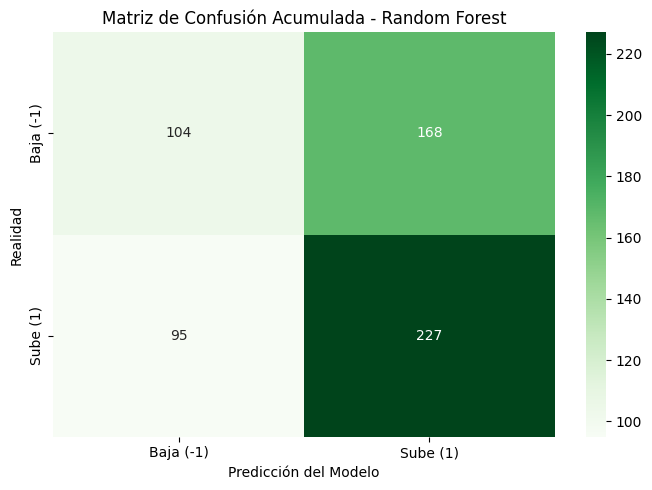

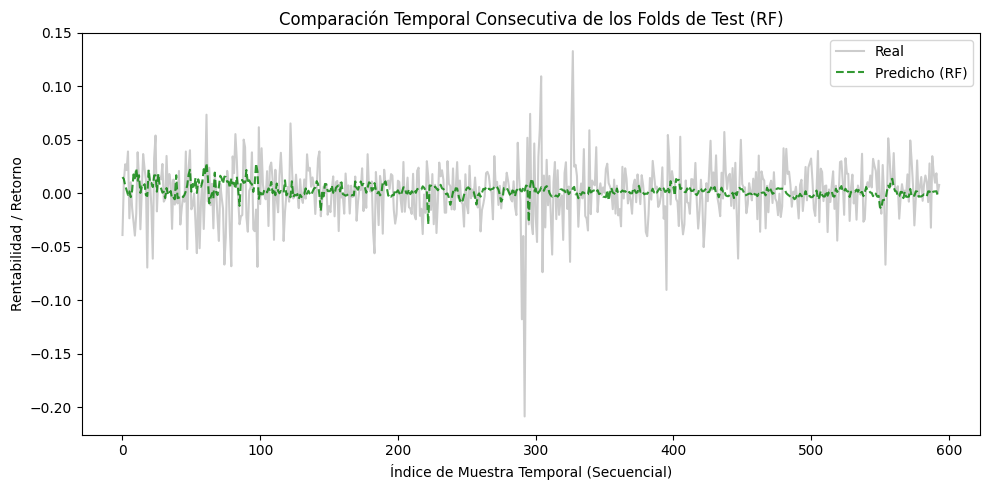

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import norm
from sklearn.metrics import (mean_squared_error, r2_score, cohen_kappa_score,
                             confusion_matrix, accuracy_score)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
import warnings

warnings.filterwarnings('ignore')

# ── FUNCIONES DE CONTRASTES ESTADÍSTICOS CORREGIDAS ───────────────────────

def pesaran_timmermann_test(y_true, y_pred):
    """Calcula el test de Pesaran-Timmermann para capacidad direccional."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    n = len(y_true)

    p_hat = (y_true == y_pred).mean()
    p_y = (y_true == 1).mean()
    p_x = (y_pred == 1).mean()
    p_star = p_y * p_x + (1 - p_y) * (1 - p_x)

    v_p_hat = (p_star * (1 - p_star)) / n
    v_p_y = (2 * p_x - 1)**2 * (p_y * (1 - p_y) / n)
    v_p_x = (2 * p_y - 1)**2 * (p_x * (1 - p_x) / n)

    v_total = v_p_hat - v_p_y - v_p_x
    if v_total <= 0: return 0.0, 1.0

    z_stat = (p_hat - p_star) / np.sqrt(v_total)
    p_value = 1 - norm.cdf(z_stat)
    return z_stat, p_value


def diebold_mariano_test(y_true, y_pred, y_benchmark, h=1):
    """Contraste DM: compara error del modelo vs Benchmark (Media Histórica)."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    y_benchmark = np.array(y_benchmark)

    e_mod = (y_true - y_pred)**2
    e_ben = (y_true - y_benchmark)**2
    d = e_ben - e_mod

    d_bar = np.mean(d)
    n = len(d)

    gamma0 = np.var(d, ddof=0)
    variance = gamma0
    for k in range(1, h):
        if n - k > 0:
            gamma_k = np.mean((d[k:] - d_bar) * (d[:-k] - d_bar))
            variance += 2 * gamma_k

    v_d = variance / n
    if v_d <= 0: return 0.0, 1.0

    dm_stat = d_bar / np.sqrt(v_d)
    p_value = 1 - norm.cdf(dm_stat)
    return dm_stat, p_value

# ── 0. CARGA DE DATOS ────────────────────────────────────────────────────

try:
    df = pd.read_csv('/content/ibex_tfg_weekly.csv')
except FileNotFoundError:
    df = pd.read_csv('ibex_tfg_weekly.csv')

date_col = 'date' if 'date' in df.columns else 'Date'
df[date_col] = pd.to_datetime(df[date_col])
df = df.sort_values(date_col)

target_col = df.columns[-1]
X_num = df.select_dtypes(include=[np.number]).drop(columns=[target_col])
y = df[target_col]

# ── 1. CONFIGURACIÓN DE PARÁMETROS (RANDOM FOREST) ───────────────────────

best_rf_params = {'n_estimators': 200, 'max_depth': 4, 'random_state': 42}
best_pca_set = [0, 1, 3, 5]
best_winsor = (0.025, 0.025)

# ── 2. VALIDACIÓN CRUZADA (6 FOLDS) ──────────────────────────────────────

tscv_6 = TimeSeriesSplit(n_splits=6)
all_preds = []
all_actuals = []
fold_detailed_results = []

print("Iniciando validación cruzada con evaluación estadística individual por fold...")

for i, (train_idx, test_idx) in enumerate(tscv_6.split(X_num)):
    X_tr, X_te = X_num.iloc[train_idx].copy(), X_num.iloc[test_idx].copy()
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    mean_benchmark = y_tr.mean()
    benchmarks_fold = [mean_benchmark] * len(y_te)

    for col in X_tr.columns:
        l = X_tr[col].quantile(best_winsor[0])
        u = X_tr[col].quantile(1 - best_winsor[1])
        X_tr[col], X_te[col] = X_tr[col].clip(l, u), X_te[col].clip(l, u)

    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr)
    X_te_s = sc.transform(X_te)

    pca = PCA(n_components=max(best_pca_set) + 1)
    X_tr_p = pca.fit_transform(X_tr_s)
    X_te_p = pca.transform(X_te_s)

    model = RandomForestRegressor(**best_rf_params)
    model.fit(X_tr_p[:, best_pca_set], y_tr)
    preds = model.predict(X_te_p[:, best_pca_set])

    all_preds.extend(preds)
    all_actuals.extend(y_te.values)

    y_te_sign = np.where(y_te.values >= 0, 1, -1)
    preds_sign = np.where(preds >= 0, 1, -1)

    cm = confusion_matrix(y_te_sign, preds_sign, labels=[-1, 1])
    recall_down = cm[0,0] / cm[0,:].sum() if cm[0,:].sum() > 0 else 0
    recall_up = cm[1,1] / cm[1,:].sum() if cm[1,:].sum() > 0 else 0

    z_pt, p_pt = pesaran_timmermann_test(y_te_sign, preds_sign)
    dm_stat, p_dm = diebold_mariano_test(y_te.values, preds, benchmarks_fold, h=1)

    fold_detailed_results.append({
        'Fold': i + 1,
        'Inicio': df[date_col].iloc[test_idx[0]].date(),
        'Fin': df[date_col].iloc[test_idx[-1]].date(),
        'Acc_Global (%)': round(accuracy_score(y_te_sign, preds_sign) * 100, 2),
        'Recall_Baja (%)': round(recall_down * 100, 2),
        'Recall_Sube (%)': round(recall_up * 100, 2),
        'Kappa': round(cohen_kappa_score(y_te_sign, preds_sign), 2),
        'RMSE': round(np.sqrt(mean_squared_error(y_te, preds)), 4),
        'R2': round(r2_score(y_te, preds), 2),
        'PT p-val': round(p_pt, 4),
        'DM p-val': round(p_dm, 4)
    })

summary_detailed_df = pd.DataFrame(fold_detailed_results)
display(summary_detailed_df)

# ── 3. RESUMEN ESTADÍSTICO EN TEXTO ──────────────────────────────────────

print("\n" + "="*60)
print("PROMEDIOS GLOBALES DE LA VALIDACIÓN CRUZADA (RF)")
print("="*60)
print(f"Promedio RMSE: {summary_detailed_df['RMSE'].mean():.4f}")
print(f"Promedio R2: {summary_detailed_df['R2'].mean():.4f}")
print(f"Promedio Accuracy Global: {summary_detailed_df['Acc_Global (%)'].mean():.2f}%")
print(f"Promedio Recall Baja (Cortos): {summary_detailed_df['Recall_Baja (%)'].mean():.2f}%")
print(f"Promedio Recall Sube (Largos): {summary_detailed_df['Recall_Sube (%)'].mean():.2f}%")
print(f"Promedio PT p-val: {summary_detailed_df['PT p-val'].mean():.4f}")
print(f"Promedio DM p-val: {summary_detailed_df['DM p-val'].mean():.4f}")
print("="*60)

# ── 4. VISUALIZACIONES GLOBALES POR SEPARADO ─────────────────────────────

y_act = np.array(all_actuals)
s_act = np.where(y_act >= 0, 1, -1)
s_pre = np.where(np.array(all_preds) >= 0, 1, -1)

# Imagen 1: Matriz de Confusión (En tono verde para diferenciarlo de XGBoost)
plt.figure(figsize=(7, 5))
cm_total = confusion_matrix(s_act, s_pre, labels=[-1, 1])
sns.heatmap(cm_total, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Baja (-1)', 'Sube (1)'], yticklabels=['Baja (-1)', 'Sube (1)'])
plt.title('Matriz de Confusión Acumulada - Random Forest')
plt.ylabel('Realidad')
plt.xlabel('Predicción del Modelo')
plt.tight_layout()
plt.show()

# Imagen 2: Comparativa Temporal
plt.figure(figsize=(10, 5))
plt.plot(all_actuals, label='Real', alpha=0.4, color='gray')
plt.plot(all_preds, label='Predicho (RF)', alpha=0.8, color='green', linestyle='--')
plt.title('Comparación Temporal Consecutiva de los Folds de Test (RF)')
plt.xlabel('Índice de Muestra Temporal (Secuencial)')
plt.ylabel('Rentabilidad / Retorno')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import ElasticNet
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score
import warnings

warnings.filterwarnings('ignore')

# ── 1. CARGA Y PREPARACIÓN DE DATOS ──────────────────────────────────────
try:
    df = pd.read_csv('/content/ibex_tfg_weekly.csv')
except FileNotFoundError:
    raise FileNotFoundError("No se encuentra el archivo 'ibex_tfg_weekly.csv'.")

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

target_col = df.columns[-1]
y = df[target_col]
# Seleccionamos solo las variables numéricas para el entrenamiento
X_num = df.drop(columns=[target_col, 'date']).select_dtypes(include=[np.number])

print(f"Target: {target_col}")
print("Modelo: Elastic Net (Incluyendo todos los años en el entrenamiento)")

# ── 2. DEFINICIÓN DEL EXPERIMENTO EXHAUSTIVO ─────────────────────────────
def run_exhaustive_elastic_net():
    # Parámetros de búsqueda (mismos que la referencia)
    winsor_limits = [(0.01, 0.01), (0.025, 0.025), (0.05, 0.05)]
    pca_sets = [
        [0], [0, 1], [0, 2], [0, 3], [0, 4],
        [0, 1, 2], [0, 1, 3], [0, 1, 4],
        [0, 1, 2, 3], [0, 1, 3, 5], [0, 1, 3, 7],
        [0, 1, 2, 3, 4, 5]
    ]

    # Hiperparámetros de Elastic Net
    elastic_params = [
        {'alpha': 0.01, 'l1_ratio': 0.2, 'random_state': 42},
        {'alpha': 0.01, 'l1_ratio': 0.5, 'random_state': 42},
        {'alpha': 0.01, 'l1_ratio': 0.8, 'random_state': 42},
        {'alpha': 0.1, 'l1_ratio': 0.5, 'random_state': 42}
    ]

    tscv = TimeSeriesSplit(n_splits=5)
    results = []

    for w_lim in winsor_limits:
        for pca_set in pca_sets:
            for params in elastic_params:
                fold_acc = []

                for train_idx, test_idx in tscv.split(X_num):
                    # Separación de datos sin filtrar años
                    X_tr, X_te = X_num.iloc[train_idx].copy(), X_num.iloc[test_idx].copy()
                    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

                    # ── PREPROCESAMIENTO POR FOLD (ANTI-LEAKAGE) ─────────
                    for col in X_tr.columns:
                        l = X_tr[col].quantile(w_lim[0])
                        u = X_tr[col].quantile(1 - w_lim[1])
                        X_tr[col] = X_tr[col].clip(l, u)
                        X_te[col] = X_te[col].clip(l, u)

                    sc = StandardScaler()
                    X_tr_s = sc.fit_transform(X_tr)
                    X_te_s = sc.transform(X_te)

                    pca = PCA(n_components=max(pca_set) + 1)
                    X_tr_p = pca.fit_transform(X_tr_s)
                    X_te_p = pca.transform(X_te_s)

                    # ── ENTRENAMIENTO Y PREDICCIÓN ───────────────────────
                    model = ElasticNet(**params)
                    model.fit(X_tr_p[:, pca_set], y_tr)
                    preds_cont = model.predict(X_te_p[:, pca_set])

                    # ── HOMOGENEIZACIÓN DE SIGNO (0 es positivo/subida) ──
                    y_te_sign = np.where(y_te.values >= 0, 1, -1)
                    preds_sign = np.where(preds_cont >= 0, 1, -1)

                    acc = (preds_sign == y_te_sign).mean()
                    fold_acc.append(acc)

                if fold_acc:
                    results.append({
                        'model': 'ElasticNet',
                        'alpha': params['alpha'],
                        'l1_ratio': params['l1_ratio'],
                        'winsor': w_lim,
                        'pca_set': pca_set,
                        'accuracy': np.mean(fold_acc)
                    })

    return pd.DataFrame(results).sort_values('accuracy', ascending=False)

# ── 3. EJECUCIÓN Y TABLA DE RESULTADOS ───────────────────────────────────
full_results = run_exhaustive_elastic_net()
print("\nTop 20 mejores configuraciones (Elastic Net):")
display(full_results.head(20))

Target: TARGET_ibex_ret_fwd1
Modelo: Elastic Net (Incluyendo todos los años en el entrenamiento)

Top 20 mejores configuraciones (Elastic Net):


,model,alpha,l1_ratio,winsor,pca_set,accuracy
133,ElasticNet,0.01,0.5,"(0.05, 0.05)","[0, 1, 3, 5]",0.582759
141,ElasticNet,0.01,0.5,"(0.05, 0.05)","[0, 1, 2, 3, 4, 5]",0.575862
129,ElasticNet,0.01,0.5,"(0.05, 0.05)","[0, 1, 2, 3]",0.570690
121,ElasticNet,0.01,0.5,"(0.05, 0.05)","[0, 1, 3]",0.570690
93,ElasticNet,0.01,0.5,"(0.025, 0.025)","[0, 1, 2, 3, 4, 5]",0.568966
37,ElasticNet,0.01,0.5,"(0.01, 0.01)","[0, 1, 3, 5]",0.567241
45,ElasticNet,0.01,0.5,"(0.01, 0.01)","[0, 1, 2, 3, 4, 5]",0.567241
101,ElasticNet,0.01,0.5,"(0.05, 0.05)","[0, 1]",0.567241
117,ElasticNet,0.01,0.5,"(0.05, 0.05)","[0, 1, 2]",0.567241
13,ElasticNet,0.01,0.5,"(0.01, 0.01)","[0, 3]",0.565517


Iniciando validación cruzada con evaluación estadística individual por fold...


,Fold,Inicio,Fin,Acc_Global (%),Recall_Baja (%),Recall_Sube (%),Kappa,RMSE,R2,PT p-val,DM p-val
0,1,2014-08-01,2016-06-17,50.51,8.00,93.88,0.02,0.0326,-0.14,0.3578,0.9557
1,2,2016-06-24,2018-05-11,55.56,30.23,75.00,0.05,0.0214,-0.03,0.2811,0.9156
2,3,2018-05-18,2020-04-03,51.52,16.98,91.30,0.08,0.0320,-0.03,0.1117,0.6920
3,4,2020-04-10,2022-02-25,52.53,0.00,100.00,0.00,0.0320,0.00,1.0000,0.1493
4,5,2022-03-04,2024-02-02,56.57,28.89,79.63,0.09,0.0226,-0.00,0.1624,0.3419
5,6,2024-02-09,2025-12-26,63.64,23.53,84.62,0.09,0.0212,-0.05,0.1592,0.3544



PROMEDIOS GLOBALES DE LA VALIDACIÓN CRUZADA (EN)
Promedio RMSE: 0.0270
Promedio R2: -0.0417
Promedio Accuracy Global: 55.05%
Promedio Recall Baja (Cortos): 17.94%
Promedio Recall Sube (Largos): 87.41%
Promedio PT p-val: 0.3454
Promedio DM p-val: 0.5682


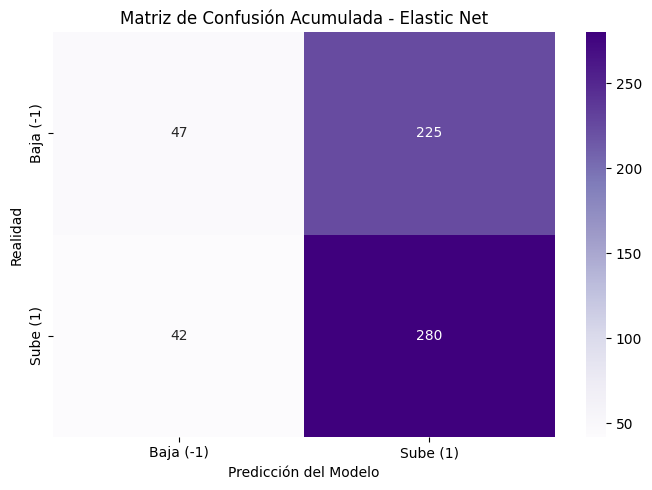

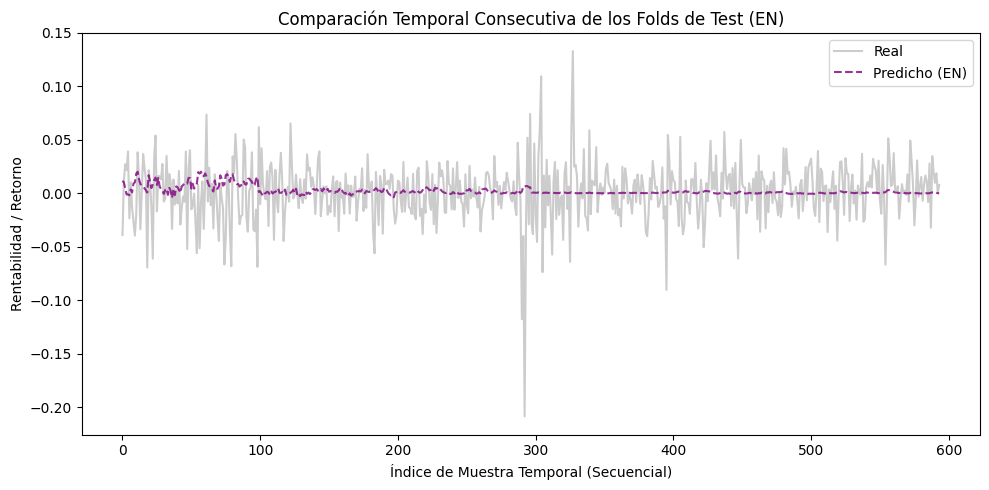

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import norm
from sklearn.metrics import (mean_squared_error, r2_score, cohen_kappa_score,
                             confusion_matrix, accuracy_score)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import ElasticNet
import warnings

warnings.filterwarnings('ignore')

# ── FUNCIONES DE CONTRASTES ESTADÍSTICOS CORREGIDAS ───────────────────────

def pesaran_timmermann_test(y_true, y_pred):
    """Calcula el test de Pesaran-Timmermann para capacidad direccional."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    n = len(y_true)

    p_hat = (y_true == y_pred).mean()
    p_y = (y_true == 1).mean()
    p_x = (y_pred == 1).mean()
    p_star = p_y * p_x + (1 - p_y) * (1 - p_x)

    v_p_hat = (p_star * (1 - p_star)) / n
    v_p_y = (2 * p_x - 1)**2 * (p_y * (1 - p_y) / n)
    v_p_x = (2 * p_y - 1)**2 * (p_x * (1 - p_x) / n)

    v_total = v_p_hat - v_p_y - v_p_x
    if v_total <= 0: return 0.0, 1.0

    z_stat = (p_hat - p_star) / np.sqrt(v_total)
    p_value = 1 - norm.cdf(z_stat)
    return z_stat, p_value


def diebold_mariano_test(y_true, y_pred, y_benchmark, h=1):
    """Contraste DM: compara error del modelo vs Benchmark (Media Histórica)."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    y_benchmark = np.array(y_benchmark)

    e_mod = (y_true - y_pred)**2
    e_ben = (y_true - y_benchmark)**2
    d = e_ben - e_mod

    d_bar = np.mean(d)
    n = len(d)

    gamma0 = np.var(d, ddof=0)
    variance = gamma0
    for k in range(1, h):
        if n - k > 0:
            gamma_k = np.mean((d[k:] - d_bar) * (d[:-k] - d_bar))
            variance += 2 * gamma_k

    v_d = variance / n
    if v_d <= 0: return 0.0, 1.0

    dm_stat = d_bar / np.sqrt(v_d)
    p_value = 1 - norm.cdf(dm_stat)
    return dm_stat, p_value

# ── 0. CARGA DE DATOS ────────────────────────────────────────────────────

try:
    df = pd.read_csv('/content/ibex_tfg_weekly.csv')
except FileNotFoundError:
    df = pd.read_csv('ibex_tfg_weekly.csv')

date_col = 'date' if 'date' in df.columns else 'Date'
df[date_col] = pd.to_datetime(df[date_col])
df = df.sort_values(date_col)

target_col = df.columns[-1]
X_num = df.select_dtypes(include=[np.number]).drop(columns=[target_col])
y = df[target_col]

# ── 1. CONFIGURACIÓN DE PARÁMETROS (ELASTIC NET GANADORA) ────────────────

best_elastic_params = {'alpha': 0.01, 'l1_ratio': 0.5, 'random_state': 42}
best_pca_set = [0, 1, 3, 5]
best_winsor = (0.05, 0.05)

# ── 2. VALIDACIÓN CRUZADA (6 FOLDS) ──────────────────────────────────────

tscv_6 = TimeSeriesSplit(n_splits=6)
all_preds = []
all_actuals = []
fold_detailed_results = []

print("Iniciando validación cruzada con evaluación estadística individual por fold...")

for i, (train_idx, test_idx) in enumerate(tscv_6.split(X_num)):
    X_tr, X_te = X_num.iloc[train_idx].copy(), X_num.iloc[test_idx].copy()
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    mean_benchmark = y_tr.mean()
    benchmarks_fold = [mean_benchmark] * len(y_te)

    for col in X_tr.columns:
        l = X_tr[col].quantile(best_winsor[0])
        u = X_tr[col].quantile(1 - best_winsor[1])
        X_tr[col], X_te[col] = X_tr[col].clip(l, u), X_te[col].clip(l, u)

    sc = StandardScaler()
    X_tr_s = sc.fit_transform(X_tr)
    X_te_s = sc.transform(X_te)

    pca = PCA(n_components=max(best_pca_set) + 1)
    X_tr_p = pca.fit_transform(X_tr_s)
    X_te_p = pca.transform(X_te_s)

    model = ElasticNet(**best_elastic_params)
    model.fit(X_tr_p[:, best_pca_set], y_tr)
    preds = model.predict(X_te_p[:, best_pca_set])

    all_preds.extend(preds)
    all_actuals.extend(y_te.values)

    y_te_sign = np.where(y_te.values >= 0, 1, -1)
    preds_sign = np.where(preds >= 0, 1, -1)

    cm = confusion_matrix(y_te_sign, preds_sign, labels=[-1, 1])
    recall_down = cm[0,0] / cm[0,:].sum() if cm[0,:].sum() > 0 else 0
    recall_up = cm[1,1] / cm[1,:].sum() if cm[1,:].sum() > 0 else 0

    z_pt, p_pt = pesaran_timmermann_test(y_te_sign, preds_sign)
    dm_stat, p_dm = diebold_mariano_test(y_te.values, preds, benchmarks_fold, h=1)

    fold_detailed_results.append({
        'Fold': i + 1,
        'Inicio': df[date_col].iloc[test_idx[0]].date(),
        'Fin': df[date_col].iloc[test_idx[-1]].date(),
        'Acc_Global (%)': round(accuracy_score(y_te_sign, preds_sign) * 100, 2),
        'Recall_Baja (%)': round(recall_down * 100, 2),
        'Recall_Sube (%)': round(recall_up * 100, 2),
        'Kappa': round(cohen_kappa_score(y_te_sign, preds_sign), 2),
        'RMSE': round(np.sqrt(mean_squared_error(y_te, preds)), 4),
        'R2': round(r2_score(y_te, preds), 2),
        'PT p-val': round(p_pt, 4),
        'DM p-val': round(p_dm, 4)
    })

summary_detailed_df = pd.DataFrame(fold_detailed_results)
display(summary_detailed_df)

# ── 3. RESUMEN ESTADÍSTICO EN TEXTO ──────────────────────────────────────

print("\n" + "="*60)
print("PROMEDIOS GLOBALES DE LA VALIDACIÓN CRUZADA (EN)")
print("="*60)
print(f"Promedio RMSE: {summary_detailed_df['RMSE'].mean():.4f}")
print(f"Promedio R2: {summary_detailed_df['R2'].mean():.4f}")
print(f"Promedio Accuracy Global: {summary_detailed_df['Acc_Global (%)'].mean():.2f}%")
print(f"Promedio Recall Baja (Cortos): {summary_detailed_df['Recall_Baja (%)'].mean():.2f}%")
print(f"Promedio Recall Sube (Largos): {summary_detailed_df['Recall_Sube (%)'].mean():.2f}%")
print(f"Promedio PT p-val: {summary_detailed_df['PT p-val'].mean():.4f}")
print(f"Promedio DM p-val: {summary_detailed_df['DM p-val'].mean():.4f}")
print("="*60)

# ── 4. VISUALIZACIONES GLOBALES POR SEPARADO ─────────────────────────────

y_act = np.array(all_actuals)
s_act = np.where(y_act >= 0, 1, -1)
s_pre = np.where(np.array(all_preds) >= 0, 1, -1)

# Imagen 1: Matriz de Confusión (En tono púrpura para Elastic Net)
plt.figure(figsize=(7, 5))
cm_total = confusion_matrix(s_act, s_pre, labels=[-1, 1])
sns.heatmap(cm_total, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Baja (-1)', 'Sube (1)'], yticklabels=['Baja (-1)', 'Sube (1)'])
plt.title('Matriz de Confusión Acumulada - Elastic Net')
plt.ylabel('Realidad')
plt.xlabel('Predicción del Modelo')
plt.tight_layout()
plt.show()

# Imagen 2: Comparativa Temporal
plt.figure(figsize=(10, 5))
plt.plot(all_actuals, label='Real', alpha=0.4, color='gray')
plt.plot(all_preds, label='Predicho (EN)', alpha=0.8, color='purple', linestyle='--')
plt.title('Comparación Temporal Consecutiva de los Folds de Test (EN)')
plt.xlabel('Índice de Muestra Temporal (Secuencial)')
plt.ylabel('Rentabilidad / Retorno')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
import itertools
import warnings
import numpy as np
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import accuracy_score

warnings.filterwarnings('ignore')

# 1. CARGA DE DATOS Y DEFINICIÓN DE 'y'
try:
    df = pd.read_csv('/content/ibex_tfg_weekly.csv')
    target_col = df.columns[-1]
    y = df[target_col].dropna()
    print(f"Variable 'y' cargada correctamente. Target: {target_col}")

    # 2. DEFINIR COMBINACIONES (d=0 fijo)
    p_vals = [0, 1, 2]
    q_vals = [0, 1, 2]
    pdq_combos = [(p, 0, q) for p in p_vals for q in q_vals]

    # Mantenemos 5 SPLITS como has pedido
    tscv = TimeSeriesSplit(n_splits=5)
    grid_results = []

    print(f'--- COMPARATIVA GLOBAL ARIMA ---')

    for pdq in pdq_combos:
        fold_accs = []
        fold_up_accs = []
        fold_down_accs = []

        for train_index, test_index in tscv.split(y):
            y_train = y.iloc[train_index].values
            y_test = y.iloc[test_index].values

            history = list(y_train)
            predictions = []

            try:
                for t in range(len(y_test)):
                    model_fit = ARIMA(history, order=pdq).fit()
                    yhat = model_fit.forecast()[0]
                    predictions.append(yhat)
                    history.append(y_test[t])

                # VERIFICACIÓN: Homogeneización del signo (>= 0 es 1)
                # Esto asegura que el 0 se trate igual que en XGBoost/RF
                y_test_bin = np.where(y_test >= 0, 1, 0)
                preds_bin = np.where(np.array(predictions) >= 0, 1, 0)

                # Accuracy General
                acc = accuracy_score(y_test_bin, preds_bin)
                fold_accs.append(acc)

                # Accuracy en Subidas (Real es 1)
                mask_up = (y_test_bin == 1)
                if np.any(mask_up):
                    fold_up_accs.append(accuracy_score(y_test_bin[mask_up], preds_bin[mask_up]))

                # Accuracy en Bajadas (Real es 0)
                mask_down = (y_test_bin == 0)
                if np.any(mask_down):
                    fold_down_accs.append(accuracy_score(y_test_bin[mask_down], preds_bin[mask_down]))

            except:
                continue

        if fold_accs:
            avg_acc = np.mean(fold_accs)
            avg_up = np.mean(fold_up_accs) if fold_up_accs else 0
            avg_down = np.mean(fold_down_accs) if fold_down_accs else 0

            print(f'ARIMA{pdq} | Acc: {avg_acc:.4f} | Up: {avg_up:.4f} | Down: {avg_down:.4f}')
            grid_results.append({
                'Config': f'ARIMA{pdq}',
                'Avg_Accuracy': avg_acc,
                'Acc_Subidas': avg_up,
                'Acc_Bajadas': avg_down
            })

    # 3. RANKING FINAL
    results_df = pd.DataFrame(grid_results).sort_values(by='Avg_Accuracy', ascending=False)
    display(results_df)

except Exception as e:
    print(f"Error al procesar: {e}")

Variable 'y' cargada correctamente. Target: TARGET_ibex_ret_fwd1
--- COMPARATIVA GLOBAL ARIMA ---
ARIMA(0, 0, 0) | Acc: 0.5431 | Up: 1.0000 | Down: 0.0000
ARIMA(0, 0, 1) | Acc: 0.5328 | Up: 0.9499 | Down: 0.0333
ARIMA(0, 0, 2) | Acc: 0.5155 | Up: 0.7655 | Down: 0.2082
ARIMA(1, 0, 0) | Acc: 0.5293 | Up: 0.9499 | Down: 0.0249
ARIMA(1, 0, 1) | Acc: 0.5207 | Up: 0.8286 | Down: 0.1668
ARIMA(1, 0, 2) | Acc: 0.4931 | Up: 0.5589 | Down: 0.4499
ARIMA(2, 0, 0) | Acc: 0.5155 | Up: 0.7582 | Down: 0.2144
ARIMA(2, 0, 1) | Acc: 0.4948 | Up: 0.6379 | Down: 0.3296
ARIMA(2, 0, 2) | Acc: 0.5259 | Up: 0.6639 | Down: 0.3656


,Config,Avg_Accuracy,Acc_Subidas,Acc_Bajadas
0,"ARIMA(0, 0, 0)",0.543103,1.000000,0.000000
1,"ARIMA(0, 0, 1)",0.532759,0.949885,0.033326
3,"ARIMA(1, 0, 0)",0.529310,0.949885,0.024877
8,"ARIMA(2, 0, 2)",0.525862,0.663896,0.365642
4,"ARIMA(1, 0, 1)",0.520690,0.828608,0.166843
2,"ARIMA(0, 0, 2)",0.515517,0.765467,0.208168
6,"ARIMA(2, 0, 0)",0.515517,0.758248,0.214402
7,"ARIMA(2, 0, 1)",0.494828,0.637881,0.329561
5,"ARIMA(1, 0, 2)",0.493103,0.558878,0.449896


 Datos cargados correctamente. Filas: 697

--- EVALUACIÓN SISTEMÁTICA: ARIMA(2, 0, 2) (6 FOLDS) ---
Calculando walk-forward... (Esto puede tardar un poco)

--- DESGLOSE DETALLADO POR FOLD ---


,Fold,Inicio Test,Fin Test,Acc_Global (%),Recall_Baja (%),Recall_Sube (%),Kappa,RMSE,R2,PT p-val,DM p-val
0,1,2014-08-01,2016-06-17,55.56,24.00,87.76,0.12,0.0316,-0.08,0.0647,0.7480
1,2,2016-06-24,2018-05-11,54.55,32.56,71.43,0.04,0.0214,-0.03,0.3344,0.7886
2,3,2018-05-18,2020-04-03,51.52,35.85,69.57,0.05,0.0328,-0.09,0.2844,0.8619
3,4,2020-04-10,2022-02-25,41.41,29.79,51.92,-0.18,0.0323,-0.02,0.9685,0.9482
4,5,2022-03-04,2024-02-02,53.54,48.89,57.41,0.06,0.0225,-0.00,0.2655,0.3894
5,6,2024-02-09,2025-12-26,58.59,44.12,66.15,0.10,0.0212,-0.05,0.1579,0.4274



PROMEDIOS GLOBALES DE LA VALIDACIÓN CRUZADA (ARIMA (2, 0, 2))
Promedio RMSE: 0.0270
Promedio R2: -0.0450
Promedio Accuracy Global: 52.53%
Promedio Recall Baja (Cortos): 35.87%
Promedio Recall Sube (Largos): 67.37%
Promedio PT p-val: 0.3459
Promedio DM p-val: 0.6939


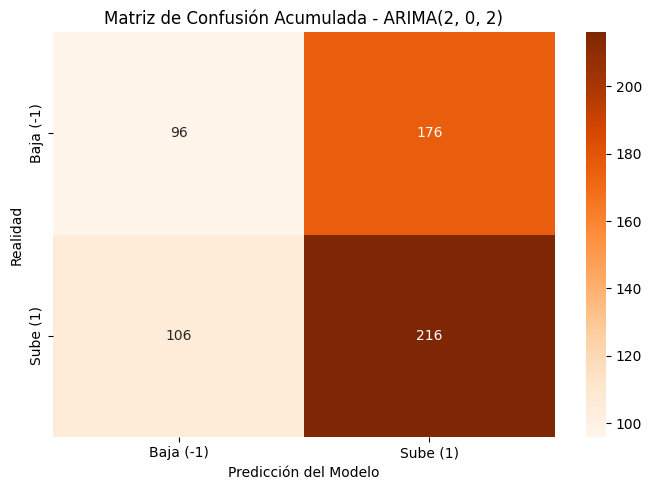

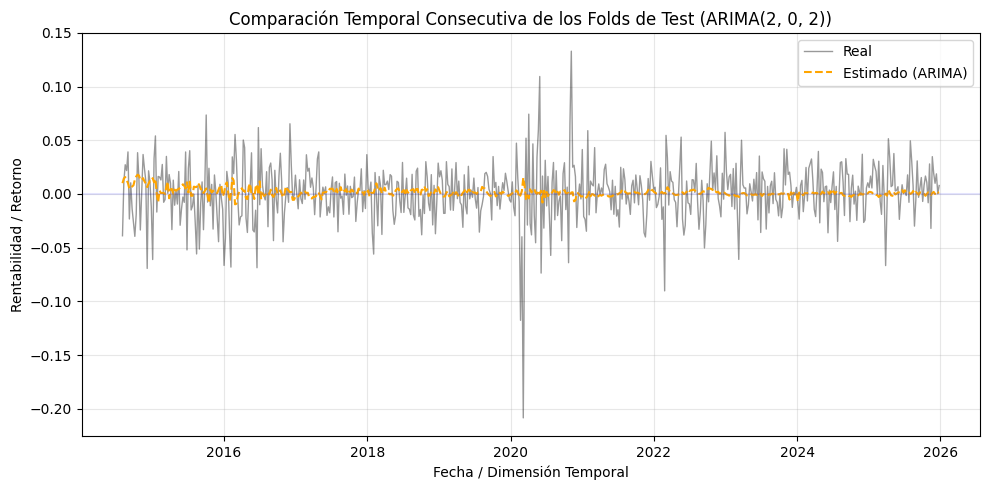

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import norm
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import (mean_squared_error, r2_score, cohen_kappa_score,
                             confusion_matrix, accuracy_score)
from sklearn.model_selection import TimeSeriesSplit
import warnings
import os

warnings.filterwarnings('ignore')

# ── FUNCIONES DE CONTRASTES ESTADÍSTICOS CORREGIDAS ───────────────────────

def pesaran_timmermann_test(y_true, y_pred):
    """Calcula el test de Pesaran-Timmermann para capacidad direccional."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    n = len(y_true)

    p_hat = (y_true == y_pred).mean()
    p_y = (y_true == 1).mean()
    p_x = (y_pred == 1).mean()
    p_star = p_y * p_x + (1 - p_y) * (1 - p_x)

    v_p_hat = (p_star * (1 - p_star)) / n
    v_p_y = (2 * p_x - 1)**2 * (p_y * (1 - p_y) / n)
    v_p_x = (2 * p_y - 1)**2 * (p_x * (1 - p_x) / n)

    v_total = v_p_hat - v_p_y - v_p_x
    if v_total <= 0: return 0.0, 1.0

    z_stat = (p_hat - p_star) / np.sqrt(v_total)
    p_value = 1 - norm.cdf(z_stat)
    return z_stat, p_value


def diebold_mariano_test(y_true, y_pred, y_benchmark, h=1):
    """Contraste DM: compara error del modelo vs Benchmark (Media Histórica)."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    y_benchmark = np.array(y_benchmark)

    e_mod = (y_true - y_pred)**2
    e_ben = (y_true - y_benchmark)**2
    d = e_ben - e_mod

    d_bar = np.mean(d)
    n = len(d)

    gamma0 = np.var(d, ddof=0)
    variance = gamma0
    for k in range(1, h):
        if n - k > 0:
            gamma_k = np.mean((d[k:] - d_bar) * (d[:-k] - d_bar))
            variance += 2 * gamma_k

    v_d = variance / n
    if v_d <= 0: return 0.0, 1.0

    dm_stat = d_bar / np.sqrt(v_d)
    p_value = 1 - norm.cdf(dm_stat)
    return dm_stat, p_value

# ── 1. CARGA DE DATOS CON VALIDACIÓN ───────────────────────────────────────

file_path = '/content/ibex_tfg_weekly.csv'

if os.path.exists(file_path):
    try:
        df = pd.read_csv(file_path)
        df.columns = df.columns.str.strip()
        date_col = next((c for c in df.columns if c.lower() in ['date', 'fecha']), None)

        if date_col:
            df[date_col] = pd.to_datetime(df[date_col])
            df = df.sort_values(date_col)

        y = df[df.columns[-1]]
        print(f' Datos cargados correctamente. Filas: {len(df)}')

        PDQ_NEW = (2, 0, 2)
        tscv_6 = TimeSeriesSplit(n_splits=6)
        all_preds, all_actuals, all_dates = [], [], []
        fold_results_list = []

        print(f'\n--- EVALUACIÓN SISTEMÁTICA: ARIMA{PDQ_NEW} (6 FOLDS) ---')
        print("Calculando walk-forward... (Esto puede tardar un poco)\n")

        for i, (train_idx, test_idx) in enumerate(tscv_6.split(y)):
            y_train, y_test = y.iloc[train_idx].values, y.iloc[test_idx].values

            mean_benchmark = np.mean(y_train)
            benchmarks_fold = [mean_benchmark] * len(y_test)

            if date_col:
                test_dates = df[date_col].iloc[test_idx]
                start_test = test_dates.min().strftime('%Y-%m-%d')
                end_test = test_dates.max().strftime('%Y-%m-%d')
                all_dates.extend(test_dates.tolist())
            else:
                start_test, end_test = "N/A", "N/A"
                all_dates.extend(range(len(all_dates), len(all_dates) + len(test_idx)))

            history = list(y_train)
            predictions = []

            for t in range(len(y_test)):
                try:
                    model_fit = ARIMA(history, order=PDQ_NEW).fit()
                    yhat = model_fit.forecast()[0]
                    predictions.append(yhat)
                except:
                    predictions.append(mean_benchmark)
                history.append(y_test[t])

            predictions = np.array(predictions)
            all_preds.extend(predictions)
            all_actuals.extend(y_test)

            # Transformación a signos (>= 0 es positivo)
            y_te_bin = np.where(y_test >= 0, 1, -1)
            preds_bin = np.where(predictions >= 0, 1, -1)

            cm = confusion_matrix(y_te_bin, preds_bin, labels=[-1, 1])
            acc = accuracy_score(y_te_bin, preds_bin)
            recall_baja = cm[0,0]/cm[0,:].sum() if cm[0,:].sum() > 0 else 0
            recall_sube = cm[1,1]/cm[1,:].sum() if cm[1,:].sum() > 0 else 0
            kappa = cohen_kappa_score(y_te_bin, preds_bin)
            rmse = np.sqrt(mean_squared_error(y_test, predictions))
            r2 = r2_score(y_test, predictions)

            # Ejecución de los tests estadísticos por fold de forma independiente
            z_pt, p_pt = pesaran_timmermann_test(y_te_bin, preds_bin)
            dm_stat, p_dm = diebold_mariano_test(y_test, predictions, benchmarks_fold, h=1)

            fold_results_list.append({
                'Fold': i + 1,
                'Inicio Test': start_test,
                'Fin Test': end_test,
                'Acc_Global (%)': round(acc * 100, 2),
                'Recall_Baja (%)': round(recall_baja * 100, 2),
                'Recall_Sube (%)': round(recall_sube * 100, 2),
                'Kappa': round(kappa, 2),
                'RMSE': round(rmse, 4),
                'R2': round(r2, 2),
                'PT p-val': round(p_pt, 4),
                'DM p-val': round(p_dm, 4)
            })

        # --- MOSTRAR RESULTADOS DETALLADOS POR FOLD ---
        df_folds = pd.DataFrame(fold_results_list)
        print('--- DESGLOSE DETALLADO POR FOLD ---')
        display(df_folds)

        # --- RESUMEN PROMEDIO EN TEXTO ---
        print("\n" + "="*60)
        print(f"PROMEDIOS GLOBALES DE LA VALIDACIÓN CRUZADA (ARIMA {PDQ_NEW})")
        print("="*60)
        print(f"Promedio RMSE: {df_folds['RMSE'].mean():.4f}")
        print(f"Promedio R2: {df_folds['R2'].mean():.4f}")
        print(f"Promedio Accuracy Global: {df_folds['Acc_Global (%)'].mean():.2f}%")
        print(f"Promedio Recall Baja (Cortos): {df_folds['Recall_Baja (%)'].mean():.2f}%")
        print(f"Promedio Recall Sube (Largos): {df_folds['Recall_Sube (%)'].mean():.2f}%")
        print(f"Promedio PT p-val: {df_folds['PT p-val'].mean():.4f}")
        print(f"Promedio DM p-val: {df_folds['DM p-val'].mean():.4f}")
        print("="*60)

        # --- VISUALIZACIONES GLOBALES POR SEPARADO ---
        y_act = np.array(all_actuals)
        s_act = np.where(y_act >= 0, 1, -1)
        s_pre = np.where(np.array(all_preds) >= 0, 1, -1)

        # Imagen 1: Matriz de Confusión (En tono naranja para diferenciarlo de los anteriores)
        plt.figure(figsize=(7, 5))
        cm_total = confusion_matrix(s_act, s_pre, labels=[-1, 1])
        sns.heatmap(cm_total, annot=True, fmt='d', cmap='Oranges',
                    xticklabels=['Baja (-1)', 'Sube (1)'], yticklabels=['Baja (-1)', 'Sube (1)'])
        plt.title(f'Matriz de Confusión Acumulada - ARIMA{PDQ_NEW}')
        plt.ylabel('Realidad')
        plt.xlabel('Predicción del Modelo')
        plt.tight_layout()
        plt.show()

        # Imagen 2: Comparativa Temporal
        plt.figure(figsize=(10, 5))
        plt.plot(all_dates, all_actuals, label='Real', color='black', alpha=0.4, linewidth=1)
        plt.plot(all_dates, all_preds, label='Estimado (ARIMA)', color='orange', linestyle='--', linewidth=1.5)
        plt.axhline(0, color='blue', linestyle='-', alpha=0.1)
        plt.title(f'Comparación Temporal Consecutiva de los Folds de Test (ARIMA{PDQ_NEW})')
        plt.xlabel('Fecha / Dimensión Temporal')
        plt.ylabel('Rentabilidad / Retorno')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f'Error procesando los datos: {e}')
else:
    print(f' ERROR: No se encontró el archivo.')

 Datos cargados correctamente. Filas: 697

--- EVALUACIÓN SISTEMÁTICA: MEDIA HISTÓRICA RECURSIVA (6 FOLDS) ---
--- DESGLOSE DETALLADO POR FOLD ---


,Fold,Inicio Test,Fin Test,Acc_Global (%),Recall_Baja (%),Recall_Sube (%),Kappa,RMSE,R2,PT p-val
0,1,2014-08-01,2016-06-17,49.49,0.0,100.0,0.0,0.0309,-0.03,1.0
1,2,2016-06-24,2018-05-11,56.57,0.0,100.0,0.0,0.0212,-0.01,1.0
2,3,2018-05-18,2020-04-03,46.46,0.0,100.0,0.0,0.0318,-0.02,1.0
3,4,2020-04-10,2022-02-25,52.53,0.0,100.0,0.0,0.0320,-0.00,1.0
4,5,2022-03-04,2024-02-02,54.55,0.0,100.0,0.0,0.0226,-0.01,1.0
5,6,2024-02-09,2025-12-26,65.66,0.0,100.0,0.0,0.0211,-0.05,1.0



PROMEDIOS GLOBALES DE LA VALIDACIÓN CRUZADA (MEDIA HISTÓRICA)
Promedio RMSE: 0.0266
Promedio R2: -0.0200
Promedio Accuracy Global: 54.21%
Promedio Recall Baja (Cortos): 0.00%
Promedio Recall Sube (Largos): 100.00%
Promedio PT p-val: 1.0000


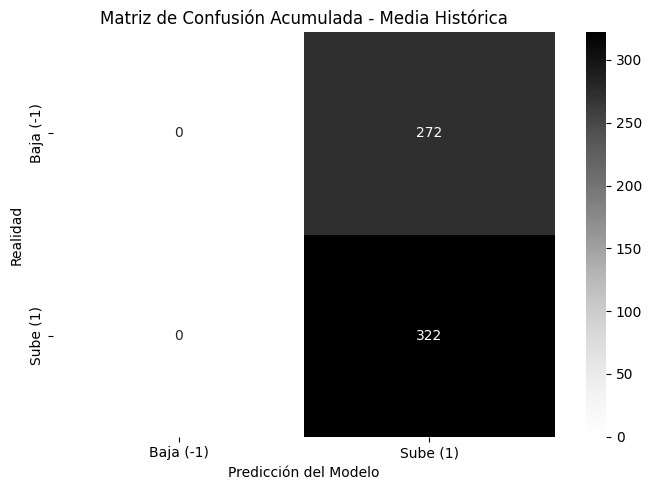

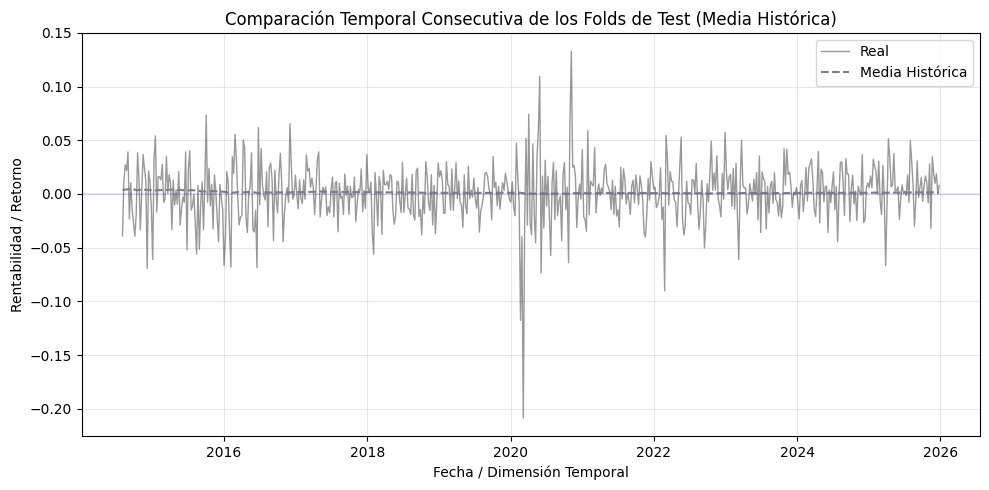

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import norm
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (mean_squared_error, r2_score, cohen_kappa_score, confusion_matrix, accuracy_score)
import warnings
import os

warnings.filterwarnings('ignore')

# ── FUNCIONES DE CONTRASTES ESTADÍSTICOS CORREGIDAS ───────────────────────

def pesaran_timmermann_test(y_true, y_pred):
    """Calcula el test de Pesaran-Timmermann para capacidad direccional."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    n = len(y_true)

    p_hat = (y_true == y_pred).mean()
    p_y = (y_true == 1).mean()
    p_x = (y_pred == 1).mean()
    p_star = p_y * p_x + (1 - p_y) * (1 - p_x)

    v_p_hat = (p_star * (1 - p_star)) / n
    v_p_y = (2 * p_x - 1)**2 * (p_y * (1 - p_y) / n)
    v_p_x = (2 * p_y - 1)**2 * (p_x * (1 - p_x) / n)

    v_total = v_p_hat - v_p_y - v_p_x
    if v_total <= 0: return 0.0, 1.0

    z_stat = (p_hat - p_star) / np.sqrt(v_total)
    p_value = 1 - norm.cdf(z_stat)
    return z_stat, p_value

# ── 1. CARGA DE DATOS ────────────────────────────────────────────────────

file_path = '/content/ibex_tfg_weekly.csv'

if os.path.exists(file_path):
    try:
        df = pd.read_csv(file_path)
        df.columns = df.columns.str.strip()
        date_col = next((c for c in df.columns if c.lower() in ['date', 'fecha']), None)

        if date_col:
            df[date_col] = pd.to_datetime(df[date_col])
            df = df.sort_values(date_col)

        y = df[df.columns[-1]]
        print(f' Datos cargados correctamente. Filas: {len(df)}')

        tscv_6 = TimeSeriesSplit(n_splits=6)
        all_preds, all_actuals, all_dates = [], [], []
        fold_results_list = []

        print('\n--- EVALUACIÓN SISTEMÁTICA: MEDIA HISTÓRICA RECURSIVA (6 FOLDS) ---')

        for i, (train_idx, test_idx) in enumerate(tscv_6.split(y)):
            y_train, y_test = y.iloc[train_idx].values, y.iloc[test_idx].values

            if date_col:
                test_dates = df[date_col].iloc[test_idx]
                start_test, end_test = test_dates.min().strftime('%Y-%m-%d'), test_dates.max().strftime('%Y-%m-%d')
                all_dates.extend(test_dates.tolist())
            else:
                start_test, end_test = "N/A", "N/A"

            history = list(y_train)
            predictions = []

            for t in range(len(y_test)):
                yhat = np.mean(history)
                predictions.append(yhat)
                history.append(y_test[t])

            predictions = np.array(predictions)
            all_preds.extend(predictions)
            all_actuals.extend(y_test)

            # Transformación a signos (>= 0 es positivo)
            y_te_bin = np.where(y_test >= 0, 1, -1)
            preds_bin = np.where(predictions >= 0, 1, -1)

            cm = confusion_matrix(y_te_bin, preds_bin, labels=[-1, 1])
            acc = accuracy_score(y_te_bin, preds_bin)
            rec_baja = cm[0,0]/cm[0,:].sum() if cm[0,:].sum() > 0 else 0
            rec_sube = cm[1,1]/cm[1,:].sum() if cm[1,:].sum() > 0 else 0
            kappa = cohen_kappa_score(y_te_bin, preds_bin)
            rmse = np.sqrt(mean_squared_error(y_test, predictions))
            r2 = r2_score(y_test, predictions)

            # Ejecución del test estadístico por fold de forma independiente
            z_pt, p_pt = pesaran_timmermann_test(y_te_bin, preds_bin)

            fold_results_list.append({
                'Fold': i + 1,
                'Inicio Test': start_test,
                'Fin Test': end_test,
                'Acc_Global (%)': round(acc * 100, 2),
                'Recall_Baja (%)': round(rec_baja * 100, 2),
                'Recall_Sube (%)': round(rec_sube * 100, 2),
                'Kappa': round(kappa, 2),
                'RMSE': round(rmse, 4),
                'R2': round(r2, 2),
                'PT p-val': round(p_pt, 4)
            })

        # --- TABLAS DETALLADAS ---
        df_folds = pd.DataFrame(fold_results_list)
        print('--- DESGLOSE DETALLADO POR FOLD ---')
        display(df_folds)

        # --- RESUMEN PROMEDIO EN TEXTO ───
        print("\n" + "="*60)
        print("PROMEDIOS GLOBALES DE LA VALIDACIÓN CRUZADA (MEDIA HISTÓRICA)")
        print("="*60)
        print(f"Promedio RMSE: {df_folds['RMSE'].mean():.4f}")
        print(f"Promedio R2: {df_folds['R2'].mean():.4f}")
        print(f"Promedio Accuracy Global: {df_folds['Acc_Global (%)'].mean():.2f}%")
        print(f"Promedio Recall Baja (Cortos): {df_folds['Recall_Baja (%)'].mean():.2f}%")
        print(f"Promedio Recall Sube (Largos): {df_folds['Recall_Sube (%)'].mean():.2f}%")
        print(f"Promedio PT p-val: {df_folds['PT p-val'].mean():.4f}")
        print("="*60)

        # --- VISUALIZACIONES GLOBALES POR SEPARADO ───────────────────────
        y_act, y_pre = np.array(all_actuals), np.array(all_preds)
        s_act, s_pre = np.where(y_act >= 0, 1, -1), np.where(y_pre >= 0, 1, -1)

        # Imagen 1: Matriz de Confesión Acumulada (En escala de grises para el Benchmark)
        plt.figure(figsize=(7, 5))
        cm_total = confusion_matrix(s_act, s_pre, labels=[-1, 1])
        sns.heatmap(cm_total, annot=True, fmt='d', cmap='Greys',
                    xticklabels=['Baja (-1)', 'Sube (1)'], yticklabels=['Baja (-1)', 'Sube (1)'])
        plt.title('Matriz de Confusión Acumulada - Media Histórica')
        plt.ylabel('Realidad')
        plt.xlabel('Predicción del Modelo')
        plt.tight_layout()
        plt.show()

        # Imagen 2: Comparativa Temporal
        plt.figure(figsize=(10, 5))
        plt.plot(all_dates, all_actuals, label='Real', color='black', alpha=0.4, linewidth=1)
        plt.plot(all_dates, all_preds, label='Media Histórica', color='gray', linestyle='--', linewidth=1.5)
        plt.axhline(0, color='blue', linestyle='-', alpha=0.1)
        plt.title('Comparación Temporal Consecutiva de los Folds de Test (Media Histórica)')
        plt.xlabel('Fecha / Dimensión Temporal')
        plt.ylabel('Rentabilidad / Retorno')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f'Error: {e}')
else:
    print(' ERROR: No se encontró el archivo.')

 Datos cargados correctamente. Archivo: ibex_tfg_weekly.csv | Filas: 697

--- EVALUACIÓN SISTEMÁTICA: MODELO NAIVE / PERSISTENCIA (6 FOLDS) ---
--- DESGLOSE DETALLADO POR FOLD (NAIVE) ---


,Fold,Inicio Test,Fin Test,Acc_Global (%),Recall_Baja (%),Recall_Sube (%),Kappa,RMSE,R2,PT p-val,DM p-val
0,1,2014-08-01,2016-06-17,51.52,52.00,51.02,0.03,0.0411,-0.83,0.3819,0.9996
1,2,2016-06-24,2018-05-11,45.45,37.21,51.79,-0.11,0.0328,-1.42,0.8632,0.9999
2,3,2018-05-18,2020-04-03,48.48,52.83,43.48,-0.04,0.0410,-0.70,0.6435,0.9651
3,4,2020-04-10,2022-02-25,44.44,40.43,48.08,-0.12,0.0452,-1.00,0.8740,0.9938
4,5,2022-03-04,2024-02-02,49.49,44.44,53.70,-0.02,0.0341,-1.29,0.5731,0.9990
5,6,2024-02-09,2025-12-26,48.48,26.47,60.00,-0.13,0.0293,-1.02,0.9094,1.0000



PROMEDIOS GLOBALES DE LA VALIDACIÓN CRUZADA (NAIVE)
Promedio RMSE: 0.0372
Promedio R2: -1.0433
Promedio Accuracy Global: 47.98%
Promedio Recall Baja (Cortos): 42.23%
Promedio Recall Sube (Largos): 51.34%
Promedio PT p-val: 0.7075
Promedio DM p-val: 0.9929


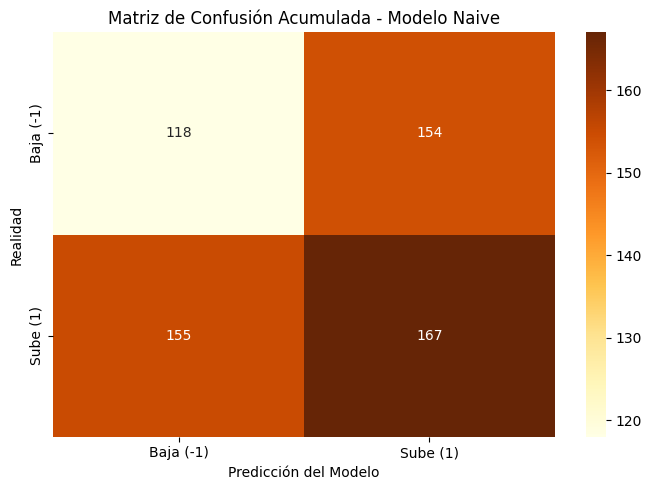

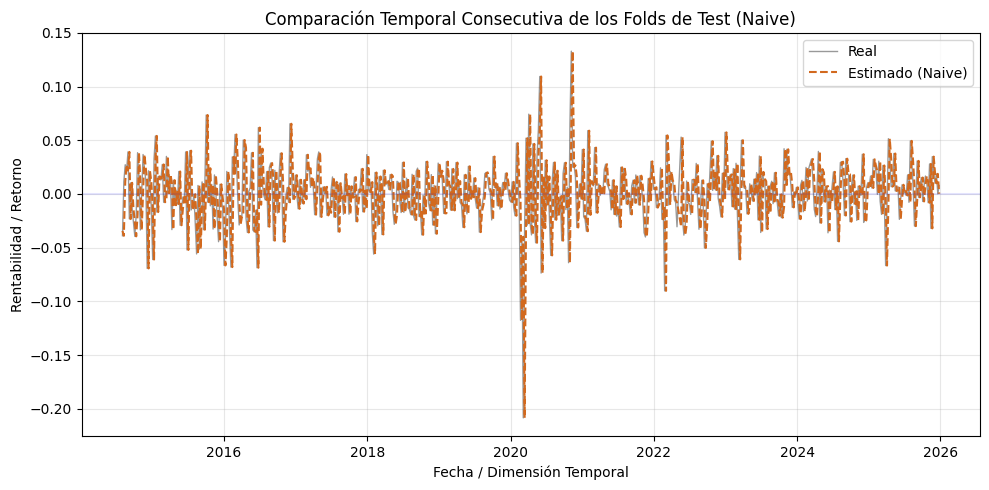

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from scipy.stats import norm
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import (mean_squared_error, r2_score, cohen_kappa_score, confusion_matrix, accuracy_score)
import warnings
import os

warnings.filterwarnings('ignore')

# ── FUNCIONES DE CONTRASTES ESTADÍSTICOS CORREGIDAS ───────────────────────

def pesaran_timmermann_test(y_true, y_pred):
    """Calcula el test de Pesaran-Timmermann para capacidad direccional."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    n = len(y_true)

    p_hat = (y_true == y_pred).mean()
    p_y = (y_true == 1).mean()
    p_x = (y_pred == 1).mean()
    p_star = p_y * p_x + (1 - p_y) * (1 - p_x)

    v_p_hat = (p_star * (1 - p_star)) / n
    v_p_y = (2 * p_x - 1)**2 * (p_y * (1 - p_y) / n)
    v_p_x = (2 * p_y - 1)**2 * (p_x * (1 - p_x) / n)

    v_total = v_p_hat - v_p_y - v_p_x
    if v_total <= 0: return 0.0, 1.0

    z_stat = (p_hat - p_star) / np.sqrt(v_total)
    p_value = 1 - norm.cdf(z_stat)
    return z_stat, p_value


def diebold_mariano_test(y_true, y_pred, y_benchmark, h=1):
    """Contraste DM: Compara el modelo (Naive) vs Benchmark (Media Histórica)."""
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    y_benchmark = np.array(y_benchmark)

    e_mod = (y_true - y_pred)**2
    e_ben = (y_true - y_benchmark)**2
    d = e_ben - e_mod

    d_bar = np.mean(d)
    n = len(d)

    gamma0 = np.var(d, ddof=0)
    variance = gamma0
    for k in range(1, h):
        if n - k > 0:
            gamma_k = np.mean((d[k:] - d_bar) * (d[:-k] - d_bar))
            variance += 2 * gamma_k

    v_d = variance / n
    if v_d <= 0: return 0.0, 1.0

    dm_stat = d_bar / np.sqrt(v_d)
    p_value = 1 - norm.cdf(dm_stat)
    return dm_stat, p_value

# ── 1. CARGA DE DATOS ────────────────────────────────────────────────────

file_path = '/content/ibex_tfg_weekly.csv'

if os.path.exists(file_path):
    try:
        df = pd.read_csv(file_path)
        df.columns = df.columns.str.strip()
        date_col = next((c for c in df.columns if c.lower() in ['date', 'fecha']), None)

        if date_col:
            df[date_col] = pd.to_datetime(df[date_col])
            df = df.sort_values(date_col)

        y = df[df.columns[-1]]
        print(f' Datos cargados correctamente. Archivo: {os.path.basename(file_path)} | Filas: {len(df)}')

        tscv_6 = TimeSeriesSplit(n_splits=6)
        all_preds, all_actuals, all_dates = [], [], []
        fold_results_list = []

        print('\n--- EVALUACIÓN SISTEMÁTICA: MODELO NAIVE / PERSISTENCIA (6 FOLDS) ---')

        for i, (train_idx, test_idx) in enumerate(tscv_6.split(y)):
            y_train, y_test = y.iloc[train_idx].values, y.iloc[test_idx].values

            if date_col:
                test_dates = df[date_col].iloc[test_idx]
                start_test, end_test = test_dates.min().strftime('%Y-%m-%d'), test_dates.max().strftime('%Y-%m-%d')
                all_dates.extend(test_dates.tolist())
            else:
                start_test, end_test = "N/A", "N/A"

            history = list(y_train)
            predictions = []
            benchmarks_fold = []

            # Walk-Forward: El modelo predice que t será igual a t-1
            for t in range(len(y_test)):
                yhat = history[-1]
                predictions.append(yhat)

                # Registramos el promedio recursivo como punto de comparación benchmark para este instante
                benchmarks_fold.append(np.mean(history))
                history.append(y_test[t])

            predictions = np.array(predictions)
            all_preds.extend(predictions)
            all_actuals.extend(y_test)

            # Transformación a signos (>= 0 es positivo)
            y_te_bin = np.where(y_test >= 0, 1, -1)
            preds_bin = np.where(predictions >= 0, 1, -1)

            cm = confusion_matrix(y_te_bin, preds_bin, labels=[-1, 1])
            acc = accuracy_score(y_te_bin, preds_bin)
            rec_baja = cm[0,0]/cm[0,:].sum() if cm[0,:].sum() > 0 else 0
            rec_sube = cm[1,1]/cm[1,:].sum() if cm[1,:].sum() > 0 else 0
            kappa = cohen_kappa_score(y_te_bin, preds_bin)
            rmse = np.sqrt(mean_squared_error(y_test, predictions))
            r2 = r2_score(y_test, predictions)

            # Contrastes individuales por cada fold de la muestra secuencial
            z_pt, p_pt = pesaran_timmermann_test(y_te_bin, preds_bin)
            dm_stat, p_dm = diebold_mariano_test(y_test, predictions, benchmarks_fold, h=1)

            fold_results_list.append({
                'Fold': i + 1,
                'Inicio Test': start_test,
                'Fin Test': end_test,
                'Acc_Global (%)': round(acc * 100, 2),
                'Recall_Baja (%)': round(rec_baja * 100, 2),
                'Recall_Sube (%)': round(rec_sube * 100, 2),
                'Kappa': round(kappa, 2),
                'RMSE': round(rmse, 4),
                'R2': round(r2, 2),
                'PT p-val': round(p_pt, 4),
                'DM p-val': round(p_dm, 4)
            })

        # --- MOSTRAR RESULTADOS DETALLADOS POR FOLD ---
        df_folds = pd.DataFrame(fold_results_list)
        print('--- DESGLOSE DETALLADO POR FOLD (NAIVE) ---')
        display(df_folds)

        # --- RESUMEN PROMEDIO EN TEXTO ---
        print("\n" + "="*60)
        print("PROMEDIOS GLOBALES DE LA VALIDACIÓN CRUZADA (NAIVE)")
        print("="*60)
        print(f"Promedio RMSE: {df_folds['RMSE'].mean():.4f}")
        print(f"Promedio R2: {df_folds['R2'].mean():.4f}")
        print(f"Promedio Accuracy Global: {df_folds['Acc_Global (%)'].mean():.2f}%")
        print(f"Promedio Recall Baja (Cortos): {df_folds['Recall_Baja (%)'].mean():.2f}%")
        print(f"Promedio Recall Sube (Largos): {df_folds['Recall_Sube (%)'].mean():.2f}%")
        print(f"Promedio PT p-val: {df_folds['PT p-val'].mean():.4f}")
        print(f"Promedio DM p-val: {df_folds['DM p-val'].mean():.4f}")
        print("="*60)

        # --- VISUALIZACIONES GLOBALES POR SEPARADO ───────────────────────
        y_act, y_pre = np.array(all_actuals), np.array(all_preds)
        s_act, s_pre = np.where(y_act >= 0, 1, -1), np.where(y_pre >= 0, 1, -1)

        # Imagen 1: Matriz de Confusión Acumulada (En tonos ocres/marrones para el Naive)
        plt.figure(figsize=(7, 5))
        cm_total = confusion_matrix(s_act, s_pre, labels=[-1, 1])
        sns.heatmap(cm_total, annot=True, fmt='d', cmap='YlOrBr',
                    xticklabels=['Baja (-1)', 'Sube (1)'], yticklabels=['Baja (-1)', 'Sube (1)'])
        plt.title('Matriz de Confusión Acumulada - Modelo Naive')
        plt.ylabel('Realidad')
        plt.xlabel('Predicción del Modelo')
        plt.tight_layout()
        plt.show()

        # Imagen 2: Comparativa Temporal
        plt.figure(figsize=(10, 5))
        plt.plot(all_dates, all_actuals, label='Real', color='black', alpha=0.4, linewidth=1)
        plt.plot(all_dates, all_preds, label='Estimado (Naive)', color='chocolate', linestyle='--', linewidth=1.5)
        plt.axhline(0, color='blue', linestyle='-', alpha=0.1)
        plt.title('Comparación Temporal Consecutiva de los Folds de Test (Naive)')
        plt.xlabel('Fecha / Dimensión Temporal')
        plt.ylabel('Rentabilidad / Retorno')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    except Exception as e:
        print(f'Error: {e}')
else:
    print(f' ERROR: No se encontró el archivo en {file_path}.')

--- SHAP VALUES RECONSTRUIDOS (Variables Originales) ---


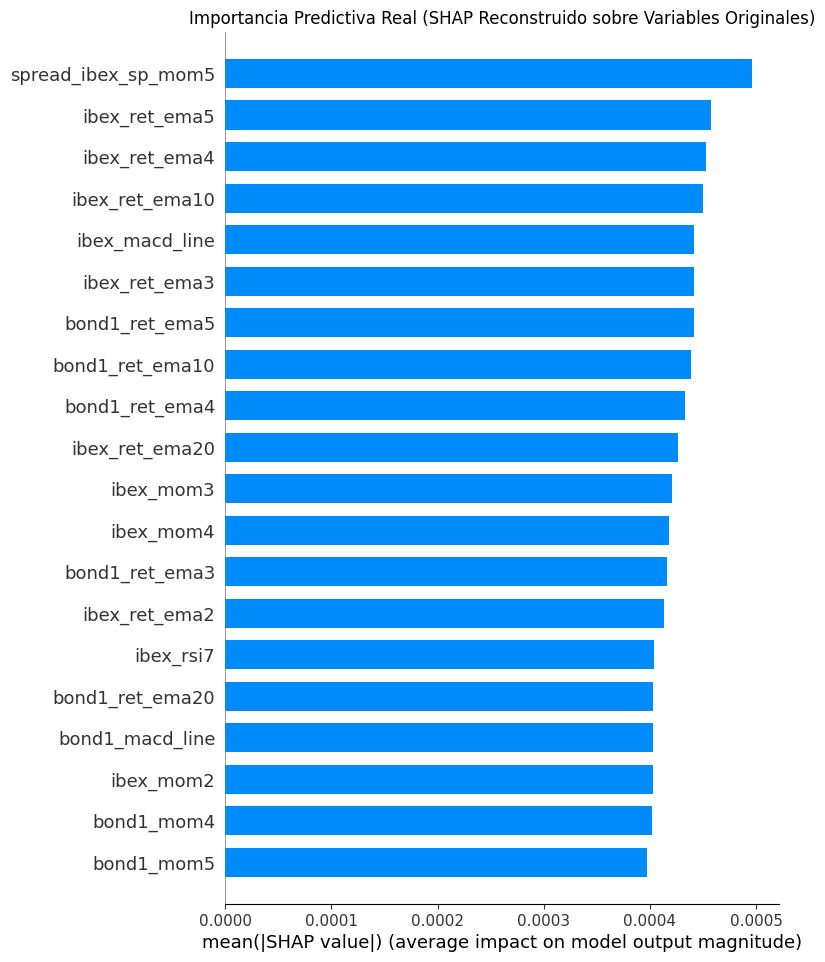


--- TOP 10 VARIABLES SEGÚN SHAP RECONSTRUIDO ---


,Variable,SHAP_Abs_Medio
293,spread_ibex_sp_mom5,0.000496
17,ibex_ret_ema5,0.000458
16,ibex_ret_ema4,0.000453
18,ibex_ret_ema10,0.000450
21,ibex_macd_line,0.000442
15,ibex_ret_ema3,0.000441
177,bond1_ret_ema5,0.000441
178,bond1_ret_ema10,0.000438
176,bond1_ret_ema4,0.000433
19,ibex_ret_ema20,0.000426


In [ ]:
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. ENTRENAMIENTO (Misma lógica de tu mejor modelo)
best_pca_indices = [0, 1, 3, 5]
sc = StandardScaler()
X_s = sc.fit_transform(X_num)
pca = PCA(n_components=max(best_pca_indices) + 1)
X_p = pca.fit_transform(X_s)

# Entrenamos con los PCs seleccionados
X_model = X_p[:, best_pca_indices]
model = XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.05)
model.fit(X_model, y)

# 2. CÁLCULO DE SHAP VALUES (Sobre los PCs)
explainer = shap.TreeExplainer(model)
shap_values_pcs = explainer.shap_values(X_model)

# 3. PROYECCIÓN DE SHAP A VARIABLES ORIGINALES

components = pca.components_[best_pca_indices, :] # Matriz (n_pcs, n_features)
shap_values_original = np.dot(shap_values_pcs, components)

# 4. VISUALIZACIÓN: SHAP SUMMARY PLOT RECONSTRUIDO
# Convertimos a DataFrame para que los nombres de las variables salgan en el gráfico
df_shap_orig = pd.DataFrame(shap_values_original, columns=X_num.columns)

print("--- SHAP VALUES RECONSTRUIDOS (Variables Originales) ---")
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values_original, X_num, plot_type="bar", show=False)
plt.title('Importancia Predictiva Real (SHAP Reconstruido sobre Variables Originales)')
plt.show()

# 5. ANÁLISIS DE CONTRIBUCIÓN MEDIA
mean_shap_importance = np.abs(shap_values_original).mean(axis=0)
df_final_shap = pd.DataFrame({
    'Variable': X_num.columns,
    'SHAP_Abs_Medio': mean_shap_importance
}).sort_values(by='SHAP_Abs_Medio', ascending=False)

print("\n--- TOP 10 VARIABLES SEGÚN SHAP RECONSTRUIDO ---")
display(df_final_shap.head(10))

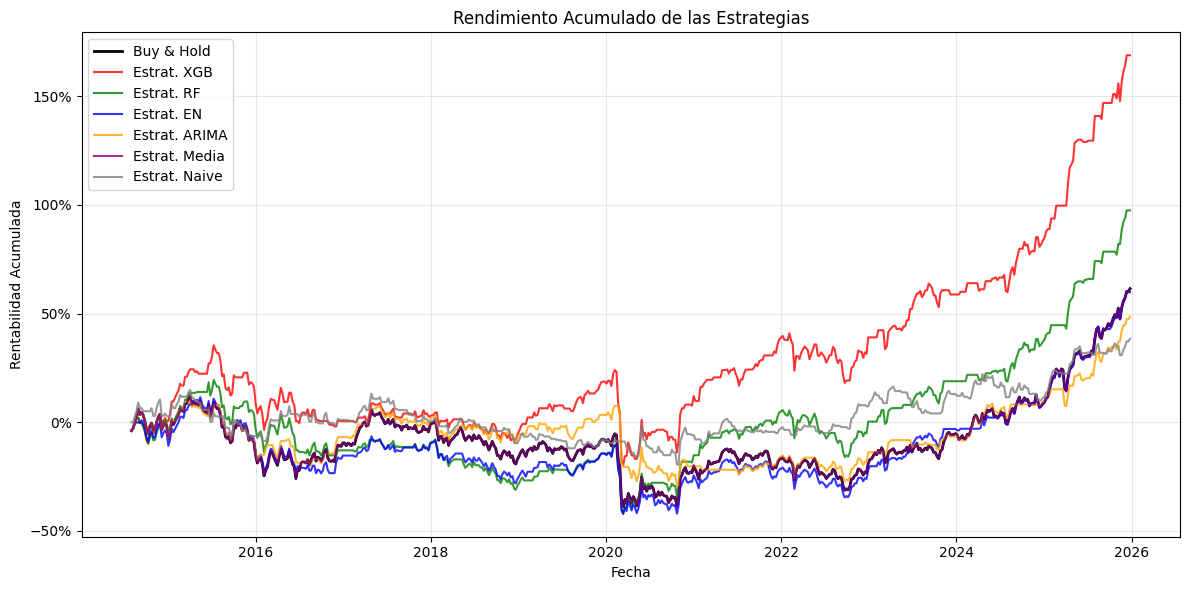

,Rent. Acumulada (%),Volatilidad Anual. (%),Ratio de Sharpe,Max Drawdown (%),Num Operaciones,% Semanas Invertido,Rotación Cartera (Turnover)
Estrategia,,,,,,,
XGB,168.82,16.82,0.60,-40.71,211,63.80%,0.3552
RF,97.47,17.42,0.43,-51.52,149,66.50%,0.2508
Buy & Hold,61.46,19.49,0.31,-45.16,1,100.00%,0.0000
EN,59.83,18.93,0.31,-48.11,77,85.02%,0.1296
Media,61.46,19.49,0.31,-45.16,0,100.00%,0.0000
ARIMA,48.58,16.58,0.29,-35.63,154,65.99%,0.2593
Naive,38.33,12.59,0.29,-29.92,309,54.04%,0.5202


In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings('ignore')

# --- Carga y preparación de datos ---
file_path = '/content/ibex_tfg_weekly.csv'

if not os.path.exists(file_path):
    raise FileNotFoundError(f"Archivo no encontrado en: {file_path}")

df = pd.read_csv(file_path)
df.columns = df.columns.str.strip()
date_col = next((c for c in df.columns if c.lower() in ['date', 'fecha']), None)

if date_col:
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(date_col)

target_col = df.columns[-1]
y = df[target_col]

cols_to_drop = [target_col]
if date_col: cols_to_drop.append(date_col)
X_num = df.select_dtypes(include=[np.number]).drop(columns=cols_to_drop, errors='ignore')

# --- Configuración de hiperparámetros óptimos ---
best_xgb_params = {'n_estimators': 100, 'learning_rate': 0.03, 'max_depth': 3, 'random_state': 42}
best_rf_params = {'n_estimators': 200, 'max_depth': 4, 'random_state': 42}
best_pca_tree = [0, 1, 3, 5]
best_winsor_tree = (0.025, 0.025)

best_en_params = {'alpha': 0.01, 'l1_ratio': 0.5, 'random_state': 42}
best_pca_en = [0, 1, 3, 5]
best_winsor_en = (0.05, 0.05)

PDQ_ARIMA = (2, 0, 2)

# --- Validación cruzada de series temporales (6 folds) ---
tscv_6 = TimeSeriesSplit(n_splits=6)

resultados = {
    'Real': [], 'Fechas': [],
    'XGB': [], 'RF': [], 'EN': [], 'ARIMA': [], 'Media': [], 'Naive': []
}

for train_idx, test_idx in tscv_6.split(X_num):
    if date_col:
        resultados['Fechas'].extend(df[date_col].iloc[test_idx].tolist())
    else:
        resultados['Fechas'].extend(range(len(resultados['Fechas']), len(resultados['Fechas']) + len(test_idx)))

    resultados['Real'].extend(y.iloc[test_idx].values)

    # Preprocesamiento y entrenamiento: Modelos basados en árboles (XGB, RF)
    X_tr_t, X_te_t = X_num.iloc[train_idx].copy(), X_num.iloc[test_idx].copy()
    for col in X_tr_t.columns:
        l, u = X_tr_t[col].quantile(best_winsor_tree[0]), X_tr_t[col].quantile(1 - best_winsor_tree[1])
        X_tr_t[col], X_te_t[col] = X_tr_t[col].clip(l, u), X_te_t[col].clip(l, u)

    sc_t = StandardScaler()
    X_tr_ts, X_te_ts = sc_t.fit_transform(X_tr_t), sc_t.transform(X_te_t)
    pca_t = PCA(n_components=max(best_pca_tree) + 1)
    X_tr_tp = pca_t.fit_transform(X_tr_ts)[:, best_pca_tree]
    X_te_tp = pca_t.transform(X_te_ts)[:, best_pca_tree]

    m_xgb = XGBRegressor(**best_xgb_params).fit(X_tr_tp, y.iloc[train_idx])
    resultados['XGB'].extend(m_xgb.predict(X_te_tp))
    m_rf = RandomForestRegressor(**best_rf_params).fit(X_tr_tp, y.iloc[train_idx])
    resultados['RF'].extend(m_rf.predict(X_te_tp))

    # Preprocesamiento y entrenamiento: Elastic Net
    X_tr_e, X_te_e = X_num.iloc[train_idx].copy(), X_num.iloc[test_idx].copy()
    for col in X_tr_e.columns:
        l, u = X_tr_e[col].quantile(best_winsor_en[0]), X_tr_e[col].quantile(1 - best_winsor_en[1])
        X_tr_e[col], X_te_e[col] = X_tr_e[col].clip(l, u), X_te_e[col].clip(l, u)

    sc_e = StandardScaler()
    X_tr_es, X_te_es = sc_e.fit_transform(X_tr_e), sc_e.transform(X_te_e)
    pca_e = PCA(n_components=max(best_pca_en) + 1)
    X_tr_ep = pca_e.fit_transform(X_tr_es)[:, best_pca_en]
    X_te_ep = pca_e.transform(X_te_es)[:, best_pca_en]

    m_en = ElasticNet(**best_en_params).fit(X_tr_ep, y.iloc[train_idx])
    resultados['EN'].extend(m_en.predict(X_te_ep))

    # Modelos basados en series temporales (ARIMA, Media Histórica, Naive)
    history = list(y.iloc[train_idx].values)
    y_test_ts = y.iloc[test_idx].values
    for t in range(len(y_test_ts)):
        resultados['Naive'].append(history[-1])
        resultados['Media'].append(np.mean(history))
        try:
            m_arima = ARIMA(history, order=PDQ_ARIMA).fit()
            resultados['ARIMA'].append(m_arima.forecast()[0])
        except:
            resultados['ARIMA'].append(np.mean(history))
        history.append(y_test_ts[t])

# --- Análisis de la simulación de trading ---
df_res = pd.DataFrame(resultados).set_index('Fechas')
modelos = ['XGB', 'RF', 'EN', 'ARIMA', 'Media', 'Naive']

df_retornos_strat = pd.DataFrame(index=df_res.index)
df_retornos_strat['Buy & Hold'] = df_res['Real']

df_posiciones = pd.DataFrame(index=df_res.index)
df_posiciones['Buy & Hold'] = 1

# Cálculo de la exposición a mercado (señal binaria) y retornos de cada estrategia
for m in modelos:
    df_posiciones[m] = np.where(df_res[m] >= 0, 1, 0)
    df_retornos_strat[m] = df_posiciones[m] * df_res['Real']

df_acum = (1 + df_retornos_strat).cumprod() - 1

# --- Construcción del gráfico de rendimiento acumulado ---
plt.figure(figsize=(12, 6))
plt.plot(df_acum['Buy & Hold'], label='Buy & Hold', color='black', lw=2)
colores = {'XGB':'red', 'RF':'green', 'EN':'blue', 'ARIMA':'orange', 'Media':'purple', 'Naive':'grey'}
for m in modelos:
    plt.plot(df_acum[m], label=f'Estrat. {m}', color=colores[m], alpha=0.8)

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.title('Rendimiento Acumulado de las Estrategias')
plt.xlabel('Fecha')
plt.ylabel('Rentabilidad Acumulada')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- Cálculo de métricas de riesgo y rendimiento ---
analisis_riesgo = []

for col in df_retornos_strat.columns:
    retornos_sim = df_retornos_strat[col]
    posicion_sim = df_posiciones[col] if col != 'Buy & Hold' else pd.Series(1, index=df_retornos_strat.index)

    rent_acum_final = df_acum[col].iloc[-1]

    # Volatilidad anualizada para datos semanales
    vol_anualizada = retornos_sim.std() * np.sqrt(52)

    # Ratio de Sharpe anualizado (tasa libre de riesgo = 0)
    mean_ret = retornos_sim.mean()
    sharpe_ratio = (mean_ret / retornos_sim.std() * np.sqrt(52)) if retornos_sim.std() > 0 else 0

    # Cálculo del Máximo Drawdown
    patrimonio = (1 + retornos_sim).cumprod()
    max_historico = patrimonio.cummax()
    drawdowns = (patrimonio - max_historico) / max_historico
    max_drawdown = drawdowns.min()

    # Métricas específicas de operativa y rotación de cartera
    if col == 'Buy & Hold':
        num_operaciones = 1
        pct_semanas_invertido = 1.0
        rotacion_cartera = 0.0
    else:
        cambios_posicion = posicion_sim.diff().dropna()
        num_operaciones = int(np.abs(cambios_posicion).sum())
        pct_semanas_invertido = posicion_sim.mean()
        rotacion_cartera = np.abs(posicion_sim.diff()).sum() / len(posicion_sim)

    analisis_riesgo.append({
        'Estrategia': col,
        'Rent. Acumulada (%)': round(rent_acum_final * 100, 2),
        'Volatilidad Anual. (%)': round(vol_anualizada * 100, 2),
        'Ratio de Sharpe': round(sharpe_ratio, 2),
        'Max Drawdown (%)': round(max_drawdown * 100, 2),
        'Num Operaciones': num_operaciones,
        '% Semanas Invertido': f"{pct_semanas_invertido * 100:.2f}%",
        'Rotación Cartera (Turnover)': round(rotacion_cartera, 4)
    })

# --- Mostrar tabla de resultados final ---
df_reporte_riesgo = pd.DataFrame(analisis_riesgo).set_index('Estrategia')
display(df_reporte_riesgo.sort_values(by='Ratio de Sharpe', ascending=False))

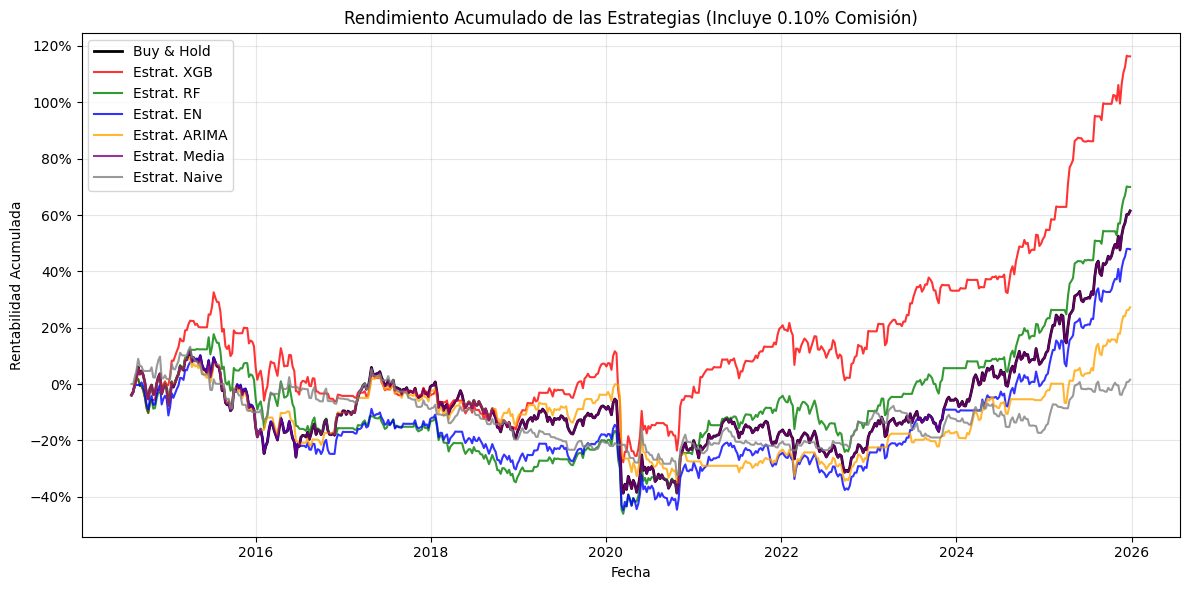

,Rent. Acumulada (%),Volatilidad Anual. (%),Ratio de Sharpe,Max Drawdown (%),Num Operaciones,% Semanas Invertido,Rotación Cartera (Turnover)
Estrategia,,,,,,,
XGB,116.31,16.83,0.49,-45.50,212,63.64%,0.3552
RF,69.97,17.42,0.36,-54.17,150,66.50%,0.2508
Buy & Hold,61.46,19.49,0.31,-45.16,1,100.00%,0.0000
Media,61.30,19.49,0.31,-45.16,1,100.00%,0.0000
EN,47.85,18.93,0.28,-49.84,78,85.02%,0.1296
ARIMA,27.24,16.59,0.21,-40.77,155,65.99%,0.2593
Naive,1.56,12.59,0.07,-40.12,309,54.04%,0.5202


In [2]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings('ignore')

# --- Carga y preparación de datos ---
file_path = '/content/ibex_tfg_weekly.csv'

if not os.path.exists(file_path):
    raise FileNotFoundError(f"Archivo no encontrado en: {file_path}")

df = pd.read_csv(file_path)
df.columns = df.columns.str.strip()
date_col = next((c for c in df.columns if c.lower() in ['date', 'fecha']), None)

if date_col:
    df[date_col] = pd.to_datetime(df[date_col])
    df = df.sort_values(date_col)

target_col = df.columns[-1]
y = df[target_col]

cols_to_drop = [target_col]
if date_col: cols_to_drop.append(date_col)
X_num = df.select_dtypes(include=[np.number]).drop(columns=cols_to_drop, errors='ignore')

# --- Configuración de hiperparámetros óptimos ---
best_xgb_params = {'n_estimators': 100, 'learning_rate': 0.03, 'max_depth': 3, 'random_state': 42}
best_rf_params = {'n_estimators': 200, 'max_depth': 4, 'random_state': 42}
best_pca_tree = [0, 1, 3, 5]
best_winsor_tree = (0.025, 0.025)

best_en_params = {'alpha': 0.01, 'l1_ratio': 0.5, 'random_state': 42}
best_pca_en = [0, 1, 3, 5]
best_winsor_en = (0.05, 0.05)

PDQ_ARIMA = (2, 0, 2)

# --- Validación cruzada de series temporales (6 folds) ---
tscv_6 = TimeSeriesSplit(n_splits=6)

resultados = {
    'Real': [], 'Fechas': [],
    'XGB': [], 'RF': [], 'EN': [], 'ARIMA': [], 'Media': [], 'Naive': []
}

for train_idx, test_idx in tscv_6.split(X_num):
    if date_col:
        resultados['Fechas'].extend(df[date_col].iloc[test_idx].tolist())
    else:
        resultados['Fechas'].extend(range(len(resultados['Fechas']), len(resultados['Fechas']) + len(test_idx)))

    resultados['Real'].extend(y.iloc[test_idx].values)

    # Preprocesamiento y entrenamiento: Modelos basados en árboles (XGB, RF)
    X_tr_t, X_te_t = X_num.iloc[train_idx].copy(), X_num.iloc[test_idx].copy()
    for col in X_tr_t.columns:
        l, u = X_tr_t[col].quantile(best_winsor_tree[0]), X_tr_t[col].quantile(1 - best_winsor_tree[1])
        X_tr_t[col], X_te_t[col] = X_tr_t[col].clip(l, u), X_te_t[col].clip(l, u)

    sc_t = StandardScaler()
    X_tr_ts, X_te_ts = sc_t.fit_transform(X_tr_t), sc_t.transform(X_te_t)
    pca_t = PCA(n_components=max(best_pca_tree) + 1)
    X_tr_tp = pca_t.fit_transform(X_tr_ts)[:, best_pca_tree]
    X_te_tp = pca_t.transform(X_te_ts)[:, best_pca_tree]

    m_xgb = XGBRegressor(**best_xgb_params).fit(X_tr_tp, y.iloc[train_idx])
    resultados['XGB'].extend(m_xgb.predict(X_te_tp))
    m_rf = RandomForestRegressor(**best_rf_params).fit(X_tr_tp, y.iloc[train_idx])
    resultados['RF'].extend(m_rf.predict(X_te_tp))

    # Preprocesamiento y entrenamiento: Elastic Net
    X_tr_e, X_te_e = X_num.iloc[train_idx].copy(), X_num.iloc[test_idx].copy()
    for col in X_tr_e.columns:
        l, u = X_tr_e[col].quantile(best_winsor_en[0]), X_tr_e[col].quantile(1 - best_winsor_en[1])
        X_tr_e[col], X_te_e[col] = X_tr_e[col].clip(l, u), X_te_e[col].clip(l, u)

    sc_e = StandardScaler()
    X_tr_es, X_te_es = sc_e.fit_transform(X_tr_e), sc_e.transform(X_te_e)
    pca_e = PCA(n_components=max(best_pca_en) + 1)
    X_tr_ep = pca_e.fit_transform(X_tr_es)[:, best_pca_en]
    X_te_ep = pca_e.transform(X_te_es)[:, best_pca_en]

    m_en = ElasticNet(**best_en_params).fit(X_tr_ep, y.iloc[train_idx])
    resultados['EN'].extend(m_en.predict(X_te_ep))

    # Modelos basados en series temporales (ARIMA, Media Histórica, Naive)
    history = list(y.iloc[train_idx].values)
    y_test_ts = y.iloc[test_idx].values
    for t in range(len(y_test_ts)):
        resultados['Naive'].append(history[-1])
        resultados['Media'].append(np.mean(history))
        try:
            m_arima = ARIMA(history, order=PDQ_ARIMA).fit()
            resultados['ARIMA'].append(m_arima.forecast()[0])
        except:
            resultados['ARIMA'].append(np.mean(history))
        history.append(y_test_ts[t])

# --- Análisis de la simulación de trading con comisiones ---
df_res = pd.DataFrame(resultados).set_index('Fechas')
modelos = ['XGB', 'RF', 'EN', 'ARIMA', 'Media', 'Naive']

df_retornos_strat = pd.DataFrame(index=df_res.index)
df_retornos_strat['Buy & Hold'] = df_res['Real']

df_posiciones = pd.DataFrame(index=df_res.index)
df_posiciones['Buy & Hold'] = 1

# Coste de comisión fijado en 0.10% (0.0010) por transacción
coste_comision = 0.0010

for m in modelos:
    posicion = np.where(df_res[m] >= 0, 1, 0)
    df_posiciones[m] = posicion

    # Detección de cambios de posición abriendo/cerrando trades
    cambios = np.abs(np.diff(np.insert(posicion, 0, 0)))

    # Descuento del coste transaccional sobre el retorno bruto
    df_retornos_strat[m] = (posicion * df_res['Real']) - (cambios * coste_comision)

df_acum = (1 + df_retornos_strat).cumprod() - 1

# --- Construcción del gráfico de rendimiento acumulado ---
plt.figure(figsize=(12, 6))
plt.plot(df_acum['Buy & Hold'], label='Buy & Hold', color='black', lw=2)
colores = {'XGB':'red', 'RF':'green', 'EN':'blue', 'ARIMA':'orange', 'Media':'purple', 'Naive':'grey'}
for m in modelos:
    plt.plot(df_acum[m], label=f'Estrat. {m}', color=colores[m], alpha=0.8)

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
plt.title('Rendimiento Acumulado de las Estrategias (Incluye 0.10% Comisión)')
plt.xlabel('Fecha')
plt.ylabel('Rentabilidad Acumulada')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- Cálculo de métricas de riesgo y rendimiento ---
analisis_riesgo = []

for col in df_retornos_strat.columns:
    retornos_sim = df_retornos_strat[col]
    posicion_sim = df_posiciones[col] if col != 'Buy & Hold' else pd.Series(1, index=df_retornos_strat.index)

    rent_acum_final = df_acum[col].iloc[-1]
    vol_anualizada = retornos_sim.std() * np.sqrt(52)

    mean_ret = retornos_sim.mean()
    sharpe_ratio = (mean_ret / retornos_sim.std() * np.sqrt(52)) if retornos_sim.std() > 0 else 0

    patrimonio = (1 + retornos_sim).cumprod()
    max_historico = patrimonio.cummax()
    drawdowns = (patrimonio - max_historico) / max_historico
    max_drawdown = drawdowns.min()

    if col == 'Buy & Hold':
        num_operaciones = 1
        pct_semanas_invertido = 1.0
        rotacion_cartera = 0.0
    else:
        cambios_posicion = np.abs(np.diff(np.insert(posicion_sim.values, 0, 0)))
        num_operaciones = int(cambios_posicion.sum())
        pct_semanas_invertido = posicion_sim.mean()
        rotacion_cartera = np.abs(posicion_sim.diff()).sum() / len(posicion_sim)

    analisis_riesgo.append({
        'Estrategia': col,
        'Rent. Acumulada (%)': round(rent_acum_final * 100, 2),
        'Volatilidad Anual. (%)': round(vol_anualizada * 100, 2),
        'Ratio de Sharpe': round(sharpe_ratio, 2),
        'Max Drawdown (%)': round(max_drawdown * 100, 2),
        'Num Operaciones': num_operaciones,
        '% Semanas Invertido': f"{pct_semanas_invertido * 100:.2f}%",
        'Rotación Cartera (Turnover)': round(rotacion_cartera, 4)
    })

# --- Mostrar tabla de resultados final ---
df_reporte_riesgo = pd.DataFrame(analisis_riesgo).set_index('Estrategia')
display(df_reporte_riesgo.sort_values(by='Ratio de Sharpe', ascending=False))